# Conditional Variational Autoencoder (CVAE) for Ground Motion Prediction Equations
## NGA-Sub Subduction Zone Dataset
### Based on Sriwastav et al. (2025) — *Machine Learning: Earth*

---

## Overview & Motivation

This notebook implements a **Conditional Variational Autoencoder (CVAE)** integrated with an **Artificial Neural Network (ANN)** for developing Ground Motion Models (GMMs) for subduction-zone earthquakes.

### Why CVAE over NLPCA or a plain ANN?

| Method | Dimensionality Reduction | Probabilistic Output | Stability | Epistemic Uncertainty |
|---|---|---|---|---|
| NLPCA | ✅ Non-linear PCA | ❌ Deterministic | ⚠️ Unstable (non-unique) | ❌ Not directly |
| ANN | ❌ None | ❌ Deterministic | ✅ Stable | ❌ Not directly |
| BNN | ❌ None | ✅ Bayesian weights | ✅ Stable | ✅ Via weight sampling |
| **CVAE** | **✅ Learned latent space** | **✅ Probabilistic encoder** | **✅ Stable** | **✅ Via ensemble sampling** |

The CVAE:
1. **Encodes** the entire response spectrum (log PSA at all periods) into a low-dimensional **latent space** (3 principal components)
2. **Conditions** both encoder and decoder on seismological parameters ($M_w$, $R_{JB}$, $V_{s30}$, depth, fault mechanism)
3. **Decodes** latent samples back into full spectra, enabling **ensemble predictions** that capture epistemic uncertainty
4. An **ANN** separately learns the mapping from seismological parameters → latent space mean/std, enabling prediction for new earthquake scenarios

---

## Pipeline Summary

```
Training phase:
  [Log PSA (N_periods)] + [Conditions C (6)] 
      → Encoder → [μ_z (3), σ_z (3)]   (latent space)
      → Reparameterize: z = μ_z + ε·σ_z
      → Decoder + C → [Log PSA reconstructed]
  Loss = λ₁·KL + λ₂·Latent Regression + λ₃·Reconstruction

ANN phase (after CVAE is trained):
  [C (6)] → ANN → [μ_z (3), σ_z (3)]   (predict latent params from seismology)

Inference phase:
  [C_new (6)] → ANN → [μ_z, σ_z]
      → Sample z ~ N(μ_z, σ_z²)  (M times = ensemble)
      → Decoder + C_new → M response spectra  (epistemic uncertainty)
```

---

## Cell 1 — Imports & Global Settings

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.gridspec import GridSpec
import seaborn as sns
from scipy import stats
from scipy.stats import norm
import warnings, pickle, os
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, Input, Model
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.decomposition import PCA

# ── Reproducibility ─────────────────────────────────────────────────────────
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

# ── Global plot style ────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.size': 10, 'axes.titlesize': 11,
    'axes.labelsize': 10, 'figure.dpi': 120,
    'savefig.dpi': 150, 'savefig.bbox': 'tight',
    'axes.grid': True, 'grid.alpha': 0.3,
})

os.makedirs('figures', exist_ok=True)
os.makedirs('models',  exist_ok=True)

print(f"TensorFlow : {tf.__version__}")
print(f"NumPy      : {np.__version__}")
print("Setup complete. All imports successful.")

TensorFlow : 2.21.0
NumPy      : 2.1.3
Setup complete. All imports successful.


## Cell 2 — Load & Inspect Dataset

The NGA-Sub flatfile contains subduction-zone ground motion records with spectral accelerations at many periods. We use the same column definitions as the BNN/ANN notebooks for consistency.

In [29]:
CSV_PATH = 'NGAsub_flatfile_filtered.csv'
df = pd.read_csv(CSV_PATH)

print(f"Records : {len(df)}")
print(f"Events  : {df['NGAsubEQID'].nunique()}")
print(f"Stations: {df['NGAsubSSN'].nunique()}")
print(f"Mw range: {df['Earthquake_Magnitude'].min():.1f} – {df['Earthquake_Magnitude'].max():.1f}")
print(f"Rjb range: {df['Rjb_km'].min():.1f} – {df['Rjb_km'].max():.1f} km")
print(f"Vs30 range: {df['Vs30_Selected_for_Analysis_m_s'].min():.0f} – {df['Vs30_Selected_for_Analysis_m_s'].max():.0f} m/s")
print()
print("Region distribution:")
print(df['DatabaseRegion'].value_counts().to_string())

Records : 8907
Events  : 188
Stations: 2894
Mw range: 4.1 – 9.1
Rjb range: 0.0 – 999.1 km
Vs30 range: 95 – 2230 m/s

Region distribution:
DatabaseRegion
Japan                    5493
Taiwan                   1247
SouthAmerica              910
Alaska                    770
Cascadia                  381
CentralAmerica&Mexico     106


## Cell 3 — Feature Engineering & Column Definitions

Following the paper and existing notebooks:
- **Inputs (C)**: $M_w$, $R_{JB}$, $\ln(R_{JB})$, $\ln(V_{s30})$, Depth, Fault Mechanism (6 features)
- **Targets (X)**: $\ln$(PSA) at 105 periods (T = 0.01–10 s) — the spectral vector that the CVAE encodes/decodes

In [30]:
# ── Region mapping ────────────────────────────────────────────────────────────
REGION_MAP = {
    'Alaska': 1, 'Cascadia': 2, 'CentralAmerica&Mexico': 3,
    'Japan': 4, 'SouthAmerica': 5, 'Taiwan': 6,
}
REGION_NAMES  = {1:'AK', 2:'CAS', 3:'CAM', 4:'JP', 5:'SA', 6:'TW'}
REGION_COLORS = {1:'#1f77b4', 2:'#ff7f0e', 3:'#d62728',
                 4:'#9467bd', 5:'#17becf', 6:'#2ca02c'}

df['Region_Flag'] = df['DatabaseRegion'].map(REGION_MAP)
df['log_Rjb']  = np.log(df['Rjb_km'].clip(lower=0.01))
df['log_Vs30'] = np.log(df['Vs30_Selected_for_Analysis_m_s'])
df['FM']       = df['Intra_Inter_Flag'].map({0: 1, 1: 2, 5: 3}).fillna(4)

# ── Conditional inputs C ─────────────────────────────────────────────────────
COND_COLS   = ['Earthquake_Magnitude', 'Rjb_km', 'log_Rjb',
               'log_Vs30', 'Hypocenter_Depth_km', 'FM']
COND_LABELS = ['Mw', 'RJB (km)', 'ln(RJB)', 'ln(Vs30)', 'Depth (km)', 'FM']

# ── PSA period columns ────────────────────────────────────────────────────────
PSA_COLS = [
    'T0pt010S','T0pt020S','T0pt022S','T0pt025S','T0pt029S',
    'T0pt030S','T0pt032S','T0pt035S','T0pt036S','T0pt040S',
    'T0pt042S','T0pt044S','T0pt045S','T0pt046S','T0pt048S',
    'T0pt050S','T0pt055S','T0pt060S','T0pt065S','T0pt067S',
    'T0pt070S','T0pt075S','T0pt080S','T0pt085S','T0pt090S',
    'T0pt095S','T0pt100S','T0pt110S','T0pt120S','T0pt130S',
    'T0pt133S','T0pt140S','T0pt150S','T0pt160S','T0pt170S',
    'T0pt180S','T0pt190S','T0pt200S','T0pt220S','T0pt240S',
    'T0pt250S','T0pt260S','T0pt280S','T0pt290S','T0pt300S',
    'T0pt320S','T0pt340S','T0pt350S','T0pt360S','T0pt380S',
    'T0pt400S','T0pt420S','T0pt440S','T0pt450S','T0pt460S',
    'T0pt480S','T0pt500S','T0pt550S','T0pt600S','T0pt650S',
    'T0pt667S','T0pt700S','T0pt750S','T0pt800S','T0pt850S',
    'T0pt900S','T0pt950S','T1pt000S','T1pt100S','T1pt200S',
    'T1pt300S','T1pt400S','T1pt500S','T1pt600S','T1pt700S',
    'T1pt800S','T1pt900S','T2pt000S','T2pt200S','T2pt400S',
    'T2pt500S','T2pt600S','T2pt800S','T3pt000S','T3pt200S',
    'T3pt400S','T3pt500S','T3pt600S','T3pt800S','T4pt000S',
    'T4pt200S','T4pt400S','T4pt600S','T4pt800S','T5pt000S',
    'T5pt500S','T6pt000S','T6pt500S','T7pt000S','T7pt500S',
    'T8pt000S','T8pt500S','T9pt000S','T9pt500S','T10pt000S',
]
PERIOD_VALUES = [
    0.01,0.02,0.022,0.025,0.029,0.03,0.032,0.035,0.036,0.04,
    0.042,0.044,0.045,0.046,0.048,0.05,0.055,0.06,0.065,0.067,
    0.07,0.075,0.08,0.085,0.09,0.095,0.1,0.11,0.12,0.13,
    0.133,0.14,0.15,0.16,0.17,0.18,0.19,0.2,0.22,0.24,
    0.25,0.26,0.28,0.29,0.3,0.32,0.34,0.35,0.36,0.38,
    0.4,0.42,0.44,0.45,0.46,0.48,0.5,0.55,0.6,0.65,
    0.667,0.7,0.75,0.8,0.85,0.9,0.95,1.0,1.1,1.2,
    1.3,1.4,1.5,1.6,1.7,1.8,1.9,2.0,2.2,2.4,
    2.5,2.6,2.8,3.0,3.2,3.4,3.5,3.6,3.8,4.0,
    4.2,4.4,4.6,4.8,5.0,5.5,6.0,6.5,7.0,7.5,
    8.0,8.5,9.0,9.5,10.0,
]

N_PERIODS  = len(PSA_COLS)      # 105 spectral periods
N_COND     = len(COND_COLS)     # 6 conditional inputs
LATENT_DIM = 3                  # 3 principal components (as in paper)

# Store metadata
EVENT_IDS   = df['NGAsubEQID'].values.astype(int)
STATION_IDS = df['NGAsubSSN'].values.astype(int)
REGION_IDS  = df['Region_Flag'].values.astype(int)
MW_ALL      = df['Earthquake_Magnitude'].values
RJB_ALL     = df['Rjb_km'].values
VS30_ALL    = df['Vs30_Selected_for_Analysis_m_s'].values
DEPTH_ALL   = df['Hypocenter_Depth_km'].values

print(f"Spectral periods (N_PERIODS)  : {N_PERIODS}")
print(f"Conditional features (N_COND) : {N_COND}")
print(f"Latent dimensions             : {LATENT_DIM}")
print(f"Condition columns: {COND_COLS}")

Spectral periods (N_PERIODS)  : 105
Conditional features (N_COND) : 6
Latent dimensions             : 3
Condition columns: ['Earthquake_Magnitude', 'Rjb_km', 'log_Rjb', 'log_Vs30', 'Hypocenter_Depth_km', 'FM']


## Cell 4 — Data Preparation, Filtering & Normalization

### Data Preparation Steps:
1. **Filter**: Keep records where all PSA values are strictly positive (required for log transform)
2. **Log-transform targets**: $Y = \ln(\text{PSA})$ — the CVAE operates in log space
3. **Normalize inputs** (conditions C): MinMaxScaler to $[0, 1]$
4. **Normalize targets** (spectral X): StandardScaler (zero mean, unit variance) — important for the KL divergence to be meaningful
5. **Split**: 70% train / 15% validation / 15% test (following the paper)

In [31]:
# ── Filter: all PSA columns must be positive ──────────────────────────────────
pos_mask   = (df[PSA_COLS] > 0).all(axis=1)
df_model   = df[pos_mask].copy().reset_index(drop=True)
print(f"Records after filtering: {len(df_model)} / {len(df)} ({100*len(df_model)/len(df):.1f}%)")

# ── Refresh metadata arrays ───────────────────────────────────────────────────
EVENT_IDS   = df_model['NGAsubEQID'].values.astype(int)
STATION_IDS = df_model['NGAsubSSN'].values.astype(int)
REGION_IDS  = df_model['Region_Flag'].values.astype(int)
MW_ALL      = df_model['Earthquake_Magnitude'].values
RJB_ALL     = df_model['Rjb_km'].values
VS30_ALL    = df_model['Vs30_Selected_for_Analysis_m_s'].values
DEPTH_ALL   = df_model['Hypocenter_Depth_km'].values

# ── Extract raw arrays ────────────────────────────────────────────────────────
C_raw = df_model[COND_COLS].values.astype(np.float32)   # conditions (N, 6)
X_raw = df_model[PSA_COLS].values.astype(np.float32)    # PSA in g  (N, 105)
Y_log = np.log(X_raw)                                   # ln(PSA)   (N, 105)

# ── Scalers ───────────────────────────────────────────────────────────────────
scaler_C = MinMaxScaler(feature_range=(0, 1))
scaler_X = StandardScaler()   # applied to ln(PSA) for CVAE input/output

C_scaled = scaler_C.fit_transform(C_raw).astype(np.float32)   # (N, 6)
X_scaled = scaler_X.fit_transform(Y_log).astype(np.float32)   # (N, 105)

print(f"C_scaled range: [{C_scaled.min():.3f}, {C_scaled.max():.3f}]")
print(f"X_scaled range: [{X_scaled.min():.3f}, {X_scaled.max():.3f}]")
print(f"X_scaled mean ≈ 0: {X_scaled.mean():.4f}, std ≈ 1: {X_scaled.std():.4f}")

# ── Train / Val / Test split: 70% / 15% / 15% ────────────────────────────────
N = len(X_scaled)
idx = np.arange(N)
idx_trainval, idx_test = train_test_split(idx, test_size=0.15, random_state=SEED)
idx_train,    idx_val  = train_test_split(idx_trainval, test_size=0.15/0.85, random_state=SEED)

X_tr, C_tr = X_scaled[idx_train], C_scaled[idx_train]
X_va, C_va = X_scaled[idx_val],   C_scaled[idx_val]
X_te, C_te = X_scaled[idx_test],  C_scaled[idx_test]

print(f"\nTrain : {len(idx_train):5d} ({100*len(idx_train)/N:.1f}%)")
print(f"Val   : {len(idx_val):5d} ({100*len(idx_val)/N:.1f}%)")
print(f"Test  : {len(idx_test):5d} ({100*len(idx_test)/N:.1f}%)")

Records after filtering: 8907 / 8907 (100.0%)
C_scaled range: [0.000, 1.000]
X_scaled range: [-4.884, 2.597]
X_scaled mean ≈ 0: -0.0000, std ≈ 1: 1.0000

Train :  6234 (70.0%)
Val   :  1336 (15.0%)
Test  :  1337 (15.0%)


## Cell 5 — Exploratory Data Analysis (EDA)

Before building the model, we visualise:
- **Figure 1**: Dataset distribution ($M_w$-$R_{JB}$, magnitude histogram, distance histogram, $V_{s30}$ distribution)
- **Figure 2**: Spectral correlation matrix (pearson $\rho$ between $\ln$PSA at different periods)

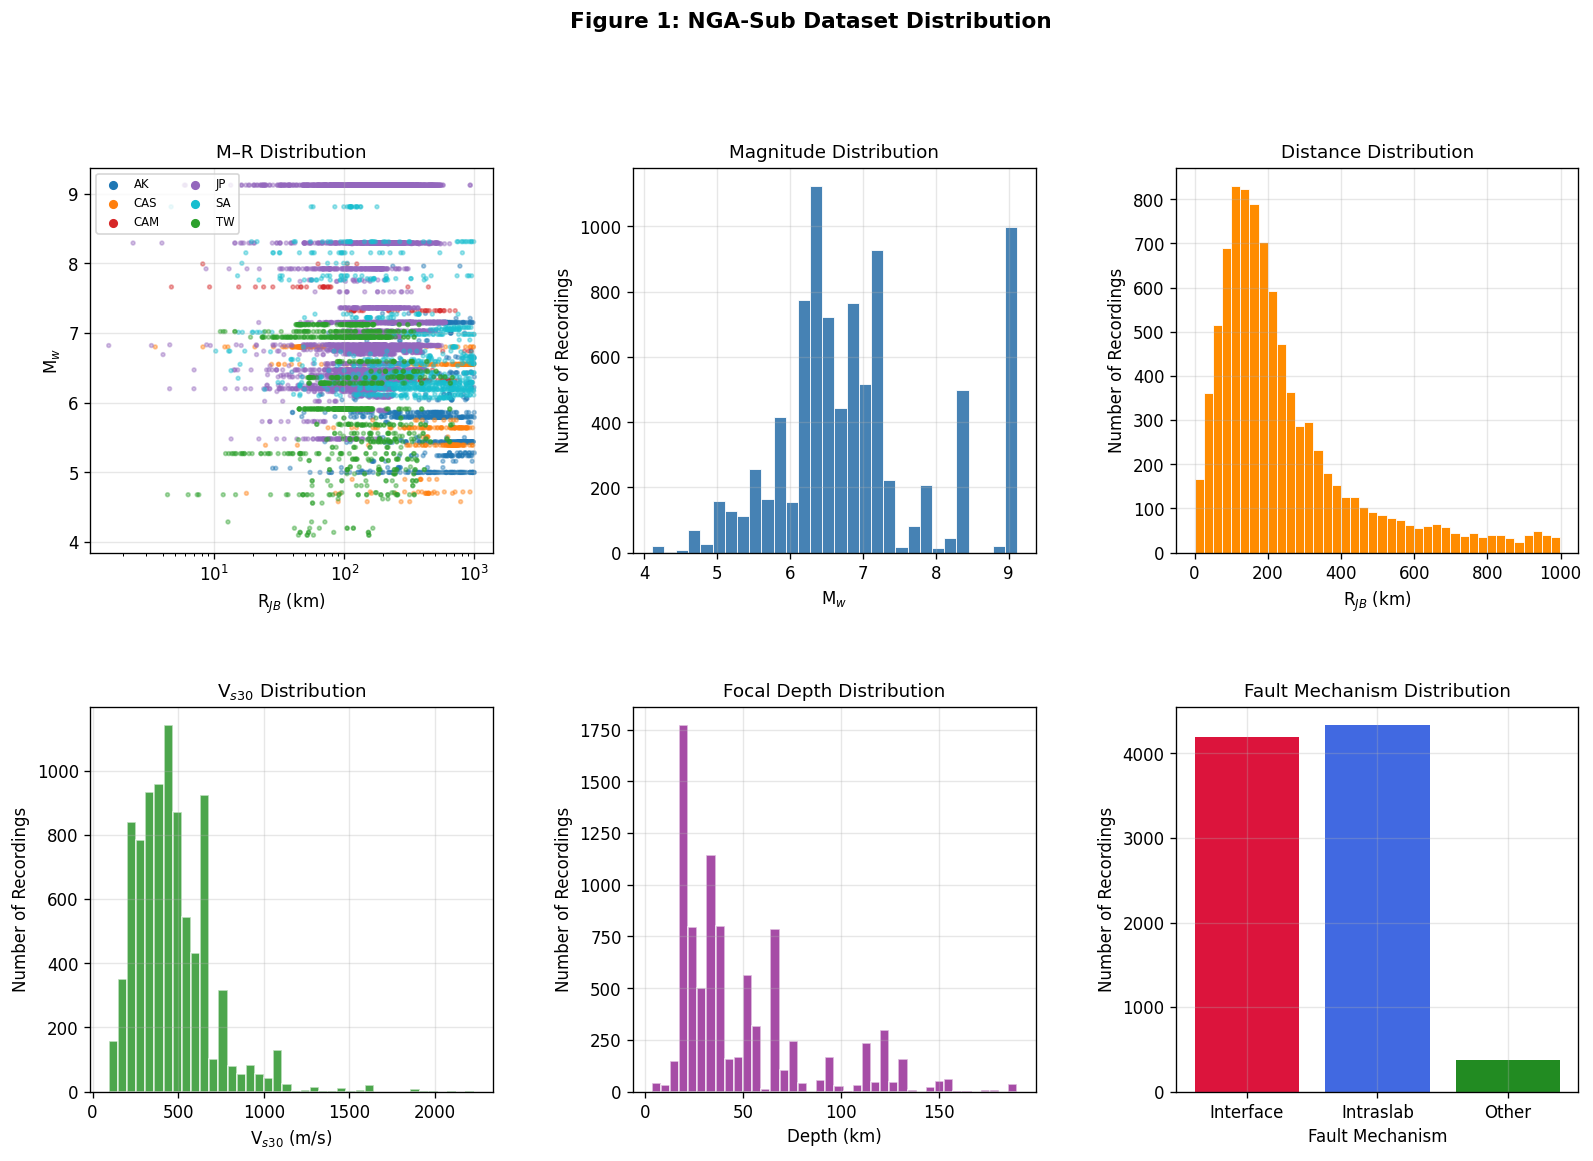

Figure 1 saved.


In [32]:
fig = plt.figure(figsize=(16, 10))
gs  = GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# ── Panel 1: M-R scatter ───────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
colors_r = [REGION_COLORS[r] for r in REGION_IDS]
ax1.scatter(RJB_ALL, MW_ALL, c=colors_r, s=5, alpha=0.4)
ax1.set_xscale('log'); ax1.set_xlabel('R$_{JB}$ (km)'); ax1.set_ylabel('M$_w$')
ax1.set_title('M–R Distribution')
for reg_id, rname in REGION_NAMES.items():
    ax1.scatter([], [], c=REGION_COLORS[reg_id], s=20, label=rname)
ax1.legend(fontsize=7, ncol=2)

# ── Panel 2: Magnitude histogram ──────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(MW_ALL, bins=30, color='steelblue', edgecolor='white', linewidth=0.5)
ax2.set_xlabel('M$_w$'); ax2.set_ylabel('Number of Recordings')
ax2.set_title('Magnitude Distribution')

# ── Panel 3: Rjb histogram ────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(RJB_ALL, bins=40, color='darkorange', edgecolor='white', linewidth=0.5)
ax3.set_xlabel('R$_{JB}$ (km)'); ax3.set_ylabel('Number of Recordings')
ax3.set_title('Distance Distribution')

# ── Panel 4: Vs30 histogram ───────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
ax4.hist(VS30_ALL, bins=40, color='green', alpha=0.7, edgecolor='white')
ax4.set_xlabel('V$_{s30}$ (m/s)'); ax4.set_ylabel('Number of Recordings')
ax4.set_title('V$_{s30}$ Distribution')

# ── Panel 5: Depth histogram ──────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
ax5.hist(DEPTH_ALL, bins=40, color='purple', alpha=0.7, edgecolor='white')
ax5.set_xlabel('Depth (km)'); ax5.set_ylabel('Number of Recordings')
ax5.set_title('Focal Depth Distribution')

# ── Panel 6: FM distribution ─────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
fm_vals = df_model['FM'].values
fm_labels = {1:'Interface', 2:'Intraslab', 3:'Other', 4:'Unknown'}
fm_counts = {fm_labels[k]: (fm_vals == k).sum() for k in fm_labels if (fm_vals == k).sum() > 0}
ax6.bar(fm_counts.keys(), fm_counts.values(), color=['crimson','royalblue','forestgreen','gray'])
ax6.set_xlabel('Fault Mechanism'); ax6.set_ylabel('Number of Recordings')
ax6.set_title('Fault Mechanism Distribution')

fig.suptitle('Figure 1: NGA-Sub Dataset Distribution', fontsize=13, fontweight='bold', y=1.01)
plt.savefig('figures/fig1_dataset_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 1 saved.")

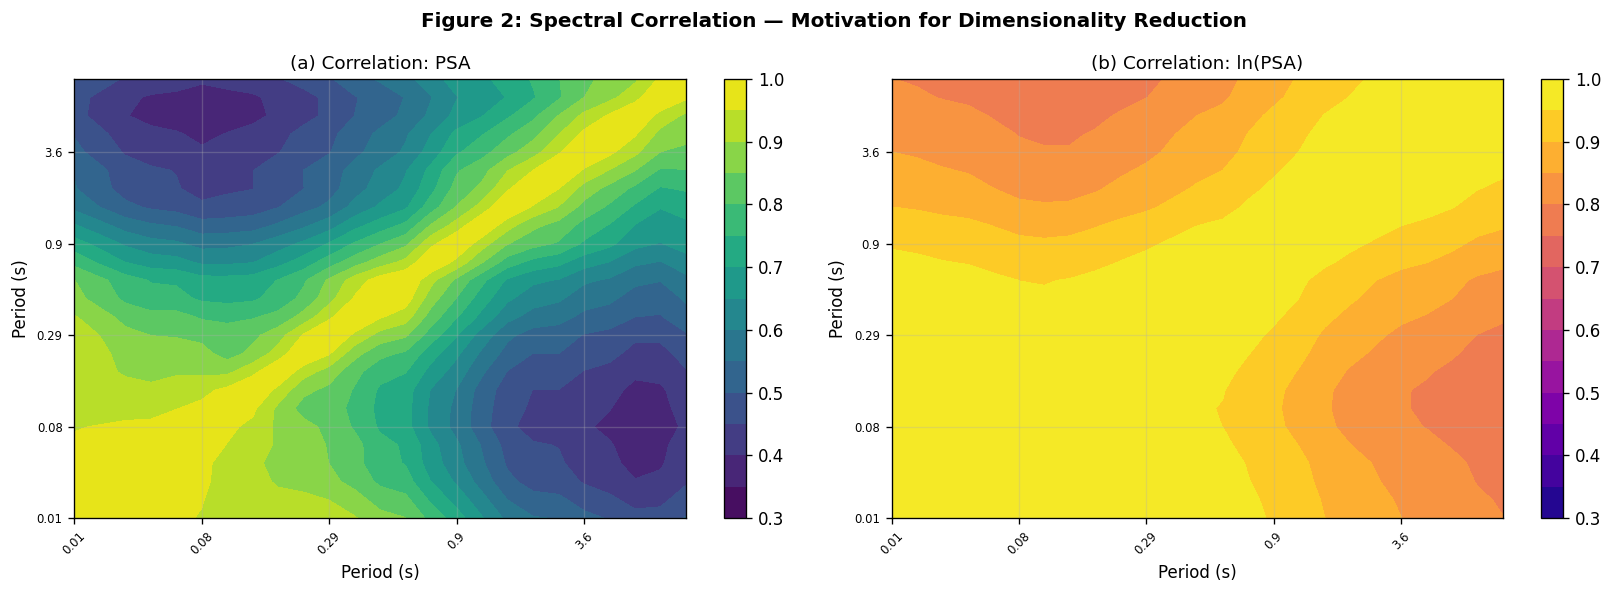

Figure 2 saved.
Minimum correlation in ln(PSA): 0.753  (high → strong redundancy)


In [33]:
# ── Figure 2: Spectral correlation matrices ────────────────────────────────────
# Correlations motivate CVAE dimensionality reduction: high correlation → redundancy

# Use a subset of periods for clear visualization
T_subset_idx = np.round(np.linspace(0, N_PERIODS-1, 25)).astype(int)  
T_labels_sub = [f"{PERIOD_VALUES[i]}" for i in T_subset_idx]

X_sub = Y_log[:, T_subset_idx]  # ln(PSA) subset
SA_sub = X_raw[:, T_subset_idx] # PSA subset (not log)

corr_ln  = np.corrcoef(X_sub.T)   # correlation of ln(PSA)
corr_raw = np.corrcoef(SA_sub.T)  # correlation of PSA

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, corr, title, cmap in zip(
        axes,
        [corr_raw, corr_ln],
        ['(a) Correlation: PSA', '(b) Correlation: ln(PSA)'],
        ['viridis', 'plasma']):
    im = ax.contourf(corr, levels=np.linspace(0.3, 1.0, 15), cmap=cmap)
    ax.set_xticks(range(0, len(T_subset_idx), 5))
    ax.set_yticks(range(0, len(T_subset_idx), 5))
    ax.set_xticklabels([T_labels_sub[i] for i in range(0, len(T_labels_sub), 5)], rotation=45, fontsize=7)
    ax.set_yticklabels([T_labels_sub[i] for i in range(0, len(T_labels_sub), 5)], fontsize=7)
    ax.set_xlabel('Period (s)'); ax.set_ylabel('Period (s)')
    ax.set_title(title)
    plt.colorbar(im, ax=ax)

fig.suptitle('Figure 2: Spectral Correlation — Motivation for Dimensionality Reduction',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fig2_spectral_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 2 saved.")
print(f"Minimum correlation in ln(PSA): {corr_ln.min():.3f}  (high → strong redundancy)")

## Cell 6 — CVAE Architecture Definition

### Architecture (following Sriwastav et al. 2025, Figure 12):

```
ENCODER:
  Input: [X (N_PERIODS=105)] concatenated with [C (6)]
  E_h1: Dense(256, ELU)
  E_h2: Dense(128, ELU)
  → mean:  Dense(LATENT_DIM=3, Linear)   ← μ of posterior q(z|x,c)
  → log_var: Dense(LATENT_DIM=3, Linear) ← log σ² of posterior

REPARAMETERIZATION:
  z = μ + ε·exp(0.5·log_var),  ε ~ N(0, I)

DECODER:
  Input: [z (LATENT_DIM)] concatenated with [C (6)]
  D_h1: Dense(128, ELU)
  D_h2: Dense(256, ELU)
  Output: Dense(N_PERIODS=105, Linear) ← reconstructed X

LOSS (Eq. 11 in paper):
  J = λ₁·KL[N(μ,σ²) ∥ N(0,I)]   (encoder regularization)
    + λ₂·‖y - ŷ‖²                 (latent regression — target y = z from CVAE)
    + λ₃·‖x - x̂‖²                 (reconstruction accuracy)
  λ₁=0.1, λ₂=1.0, λ₃=10.0
```

ELU activations prevent vanishing gradients and handle negative inputs gracefully.
Adam optimizer with learning rate 0.001, batch size 32, 300 epochs.

In [34]:
# ── Sampling layer (reparameterization trick) ─────────────────────────────────
class Sampling(layers.Layer):
    """
    Reparameterization trick: z = μ + ε·σ,  ε ~ N(0, I)
    
    Why this works:
    - Backpropagation cannot flow through a stochastic node (random sampling)
    - By writing z = μ + ε·σ we factor out the randomness into ε (not a parameter)
    - Gradients flow through μ and σ normally
    """
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon


def build_encoder(n_periods, n_cond, latent_dim,
                  hidden_dims=(256, 128), name='Encoder'):
    """
    CVAE Encoder: maps (X, C) → (μ_z, log_σ²_z)
    
    Parameters
    ----------
    n_periods  : int — dimension of spectral input X (105 periods)
    n_cond     : int — number of conditional features C (6)
    latent_dim : int — dimension of latent space (3 PCs)
    hidden_dims: tuple — neurons per hidden layer in encoder
    """
    x_inp = Input(shape=(n_periods,), name='X_input')  # spectral ordinate
    c_inp = Input(shape=(n_cond,),    name='C_input')  # conditions
    
    # Concatenate X and C (conditioning on seismological parameters)
    h = layers.Concatenate(name='XC_concat')([x_inp, c_inp])
    
    # Hidden layers with ELU activation
    for i, units in enumerate(hidden_dims):
        h = layers.Dense(units, activation='elu',
                          name=f'E_h{i+1}')(h)
    
    # Latent space parameters
    z_mean    = layers.Dense(latent_dim, name='z_mean')(h)     # μ of q(z|x,c)
    z_log_var = layers.Dense(latent_dim, name='z_log_var')(h)  # log σ² of q(z|x,c)
    z         = Sampling(name='z_sample')([z_mean, z_log_var]) # sampled z
    
    return Model([x_inp, c_inp],
                 [z_mean, z_log_var, z],
                 name=name)


def build_decoder(n_periods, n_cond, latent_dim,
                  hidden_dims=(128, 256), name='Decoder'):
    """
    CVAE Decoder: maps (z, C) → X̂ (reconstructed spectrum)
    
    Note the reversed hidden dims relative to encoder (128→256 mirrors 256→128)
    """
    z_inp = Input(shape=(latent_dim,), name='z_input')  # latent sample
    c_inp = Input(shape=(n_cond,),     name='C_input')  # conditions
    
    # Concatenate latent z and conditions C
    h = layers.Concatenate(name='ZC_concat')([z_inp, c_inp])
    
    for i, units in enumerate(hidden_dims):
        h = layers.Dense(units, activation='elu',
                          name=f'D_h{i+1}')(h)
    
    # Reconstruction — linear output (predicts normalized log PSA)
    x_hat = layers.Dense(n_periods, name='X_reconstructed')(h)
    
    return Model([z_inp, c_inp], x_hat, name=name)


# ── Instantiate encoder and decoder ──────────────────────────────────────────
encoder = build_encoder(N_PERIODS, N_COND, LATENT_DIM)
decoder = build_decoder(N_PERIODS, N_COND, LATENT_DIM)

encoder.summary()
print("\n" + "="*60)
decoder.summary()

Model: "Encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ X_input             │ (None, 105)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ C_input             │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ XC_concat           │ (None, 111)       │          0 │ X_input[0][0],    │
│ (Concatenate)       │                   │            │ C_input[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ E_h1 (Dense)        │ (None, 256)       │     28,672 │ XC_concat[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ E_h2 (Dense)        │ (None, 128)       │     32,896 │ E_h1[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 3)         │        387 │ E_h2[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 3)         │        387 │ E_h2[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_sample (Sampling) │ (None, 3)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 62,342 (243.52 KB)

 Trainable params: 62,342 (243.52 KB)

 Non-trainable params: 0 (0.00 B)

Model: "Decoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ z_input             │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ C_input             │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ZC_concat           │ (None, 9)         │          0 │ z_input[0][0],    │
│ (Concatenate)       │                   │            │ C_input[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ D_h1 (Dense)        │ (None, 128)       │      1,280 │ ZC_concat[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ D_h2 (Dense)        │ (None, 256)       │     33,024 │ D_h1[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ X_reconstructed     │ (None, 105)       │     26,985 │ D_h2[0][0]        │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 61,289 (239.41 KB)

 Trainable params: 61,289 (239.41 KB)

 Non-trainable params: 0 (0.00 B)

## Cell 7 — CVAE Model with Custom Loss

### Loss Function (Equation 11 in Sriwastav et al. 2025)

$$J(\theta, \rho; x) = \lambda_1 \cdot \text{KL}[N(\mu, \sigma^2) \| N(0, I)] + \lambda_2 \cdot \frac{1}{m}\sum_{i=1}^{m}\|y_i - \hat{y}_i\|^2 + \lambda_3 \cdot \frac{1}{n}\sum_{i=1}^{n}\|x_i - \hat{x}_i\|^2$$

Where:
- **$J_1$ (KL loss)**: Forces the latent distribution $q(z|x,c)$ to stay close to the prior $N(0,I)$. Controls regularization. Weight $\lambda_1 = 0.1$ (low → preserve meaningful structure)
- **$J_2$ (Latent regression)**: Ensures the encoder's mean $\mu$ is close to target latent values $y$ (used by the ANN branch). Weight $\lambda_2 = 1.0$
- **$J_3$ (Reconstruction)**: The main objective — reconstructed spectrum should match input. Weight $\lambda_3 = 10.0$ (high → prioritize accurate spectra)

### KL Divergence (closed form):
$$\text{KL}[N(\mu, \sigma^2) \| N(0, I)] = \frac{1}{2} \sum_j (-\log \sigma_j^2 + \mu_j^2 + \sigma_j^2 - 1)$$

In [35]:
class CVAEModel(keras.Model):
    """
    Full CVAE model with custom train_step implementing the three-component loss.
    
    The model wraps encoder + decoder and computes:
      loss = λ₁·KL + λ₂·latent_regr + λ₃·reconstruction
    
    We track each component separately for monitoring training dynamics.
    """

    def __init__(self, encoder, decoder,
                 lambda1=0.1, lambda2=1.0, lambda3=10.0, **kwargs):
        super().__init__(**kwargs)
        self.encoder  = encoder
        self.decoder  = decoder
        self.lambda1  = lambda1   # KL weight — prevents over-regularization
        self.lambda2  = lambda2   # Latent regression weight
        self.lambda3  = lambda3   # Reconstruction weight — highest priority

        # Metric trackers (shown in progress bar during training)
        self.total_loss_tracker  = keras.metrics.Mean(name='total_loss')
        self.kl_loss_tracker     = keras.metrics.Mean(name='kl_loss')
        self.lat_loss_tracker    = keras.metrics.Mean(name='lat_loss')
        self.recon_loss_tracker  = keras.metrics.Mean(name='recon_loss')

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.kl_loss_tracker,
                self.lat_loss_tracker, self.recon_loss_tracker]

    def _compute_losses(self, x, c):
        """Core loss computation, shared between train_step and test_step."""
        # Encoder forward pass
        z_mean, z_log_var, z = self.encoder([x, c])

        # Decoder forward pass (reconstruction)
        x_hat = self.decoder([z, c])

        # J3: Reconstruction loss — MSE in normalized ln(PSA) space
        recon_loss = tf.reduce_mean(
            tf.reduce_sum(tf.square(x - x_hat), axis=1)
        ) / tf.cast(tf.shape(x)[1], tf.float32)

        # J1: KL divergence (closed form for diagonal Gaussian vs N(0,I))
        # KL = 0.5 * sum(-log_var + exp(log_var) + mean² - 1)
        kl_loss = tf.reduce_mean(
            0.5 * tf.reduce_sum(
                -z_log_var + tf.exp(z_log_var) + tf.square(z_mean) - 1.0,
                axis=1
            )
        )

        # J2: Latent regression — z_mean should approximate z
        # (ensures the mean is a good deterministic estimate)
        lat_loss = tf.reduce_mean(
            tf.reduce_sum(tf.square(z_mean - z), axis=1)
        ) / tf.cast(tf.shape(z)[1], tf.float32)

        # Total loss (Eq. 11)
        total = (self.lambda1 * kl_loss
                 + self.lambda2 * lat_loss
                 + self.lambda3 * recon_loss)

        return total, kl_loss, lat_loss, recon_loss

    def train_step(self, data):
        (x, c) = data
        with tf.GradientTape() as tape:
            total, kl, lat, recon = self._compute_losses(x, c)
        grads = tape.gradient(total, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))
        self.total_loss_tracker.update_state(total)
        self.kl_loss_tracker.update_state(kl)
        self.lat_loss_tracker.update_state(lat)
        self.recon_loss_tracker.update_state(recon)
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        (x, c) = data
        total, kl, lat, recon = self._compute_losses(x, c)
        self.total_loss_tracker.update_state(total)
        self.kl_loss_tracker.update_state(kl)
        self.lat_loss_tracker.update_state(lat)
        self.recon_loss_tracker.update_state(recon)
        return {m.name: m.result() for m in self.metrics}

    def call(self, inputs):
        x, c = inputs
        z_mean, z_log_var, z = self.encoder([x, c])
        return self.decoder([z_mean, c])  # use mean for deterministic prediction

    def encode(self, x, c):
        """Returns z_mean, z_log_var, z_sample."""
        return self.encoder([x, c])

    def decode(self, z, c):
        """Decode latent z given conditions c."""
        return self.decoder([z, c])

    def sample_spectra(self, c_scaled, n_samples=100):
        """
        Generate ensemble of n_samples spectra for given conditions.
        Used at inference to quantify epistemic uncertainty.
        
        Returns array of shape (n_samples, N_PERIODS) in normalized ln space.
        """
        # Repeat conditions for each sample
        c_rep = tf.tile(c_scaled[tf.newaxis, :], [n_samples, 1])  # (n_samples, n_cond)
        # Sample z from prior N(0, I)
        z = tf.random.normal((n_samples, LATENT_DIM))
        return self.decoder([z, c_rep]).numpy()


print("CVAEModel class defined successfully.")

CVAEModel class defined successfully.


## Cell 8 — Compile & Train CVAE

**Training settings** (from paper):
- Optimizer: **Adam** (lr = 0.001)
- Batch size: **32**
- Epochs: **300** (with early stopping on validation loss, patience = 30)
- Loss weights: $\lambda_1=0.1$, $\lambda_2=1.0$, $\lambda_3=10.0$

The loss tracking helps diagnose training:
- **KL loss** should increase initially then stabilize (encoder learning a structured latent space)
- **Reconstruction loss** should decrease steadily
- **Val total loss ≈ Train total loss** → no overfitting

In [36]:
import tensorflow as tf
from tensorflow.keras import callbacks
from tensorflow.keras.optimizers import Adam

# ── Final CVAE Model Class ──────────────────────────────────────────────────
class CVAEModel(tf.keras.Model):
    def __init__(self, encoder, decoder, lambda1, lambda2, lambda3, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.lambda1 = lambda1
        self.lambda2 = lambda2
        self.lambda3 = lambda3

    def call(self, inputs, training=False):
        """Standard forward pass."""
        x, c = inputs
        enc_out = self.encoder([x, c], training=training)
        # Assumes encoder returns [z_mean, z_log_var, z]
        z = enc_out[2] if isinstance(enc_out, list) else enc_out
        reconstruction = self.decoder([z, c], training=training)
        return reconstruction

    def _compute_losses(self, x, c):
        """Calculates the weighted components of the CVAE loss."""
        # 1. Forward pass through encoder
        # IMPORTANT: Assumes your encoder returns [mean, log_var, sampled_z]
        z_mean, z_log_var, z = self.encoder([x, c])

        # 2. Forward pass through decoder
        reconstruction = self.decoder([z, c])

        # 3. Reconstruction Loss (MSE) - Weighted by λ3
        # Using direct math to avoid Keras versioning errors
        recon_loss = tf.reduce_mean(tf.reduce_sum(
            tf.square(x - reconstruction), axis=-1
        ))

        # 4. KL Divergence - Weighted by λ1
        kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
        kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=-1))

        # 5. Latent Regression Loss - Weighted by λ2
        # Use tf.shape for robustness with the conditions vector
        lat_loss = tf.reduce_mean(tf.square(z_mean - c[:, :tf.shape(z_mean)[1]]))

        # Total Weighted Loss
        total_loss = (self.lambda1 * kl_loss + 
                      self.lambda2 * lat_loss + 
                      self.lambda3 * recon_loss)

        return total_loss, kl_loss, lat_loss, recon_loss

    def train_step(self, data):
        inputs = data[0] if isinstance(data, tuple) else data
        x, c = inputs

        with tf.GradientTape() as tape:
            total_loss, kl, lat, recon = self._compute_losses(x, c)

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        # UPDATED KEYS TO MATCH YOUR PLOTTING SCRIPT
        return {
            "total_loss": total_loss,
            "kl_loss": kl,
            "lat_loss": lat,      # Changed from 'latent_loss'
            "recon_loss": recon
        }

    def test_step(self, data):
        inputs = data[0] if isinstance(data, tuple) else data
        x, c = inputs
        total_loss, kl, lat, recon = self._compute_losses(x, c)
        
        # UPDATED KEYS TO MATCH YOUR PLOTTING SCRIPT
        return {
            "total_loss": total_loss,
            "kl_loss": kl,
            "lat_loss": lat,      # Changed from 'latent_loss'
            "recon_loss": recon
        }

# ── Hyperparameters ───────────────────────────────────────────────────────────
LAMBDA1    = 0.1    
LAMBDA2    = 1.0    
LAMBDA3    = 10.0   
LR         = 0.001
BATCH_SIZE = 32
EPOCHS     = 300
PATIENCE   = 50

# ── Build & Compile ───────────────────────────────────────────────────────────
cvae = CVAEModel(encoder, decoder,
                 lambda1=LAMBDA1, lambda2=LAMBDA2, lambda3=LAMBDA3,
                 name='CVAE_GMM')

cvae.compile(optimizer=Adam(learning_rate=LR))

# Warm-up call
_ = cvae([X_tr[:2], C_tr[:2]])
print(f"Total trainable parameters: {cvae.count_params():,}")

# ── Callbacks ─────────────────────────────────────────────────────────────────
# Note: 'loss' here refers to the 'loss' key returned in train_step
cb_list = [
    callbacks.EarlyStopping(monitor='val_loss',
                            patience=PATIENCE,
                            restore_best_weights=True,
                            verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss',
                                factor=0.5, patience=15,
                                min_lr=1e-5, verbose=0),
    callbacks.ModelCheckpoint('models/cvae_best.weights.h5',
                               monitor='val_loss',
                               save_best_only=True,
                               save_weights_only=True,
                               verbose=0),
]

# ── Train ─────────────────────────────────────────────────────────────────────
print(f"Training CVAE: {EPOCHS} epochs, batch size {BATCH_SIZE}")
print(f"Loss weights: λ₁={LAMBDA1}, λ₂={LAMBDA2}, λ₃={LAMBDA3}")
print("-" * 60)

history = cvae.fit(
    (X_tr, C_tr),
    validation_data=((X_va, C_va),),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=cb_list,
    verbose=1,
)

print("\nCVAE training complete.")

Total trainable parameters: 123,631
Training CVAE: 300 epochs, batch size 32
Loss weights: λ₁=0.1, λ₂=1.0, λ₃=10.0
------------------------------------------------------------
Epoch 1/300
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - kl_loss: 12.5564 - lat_loss: 2.7980 - recon_loss: 1.2098 - total_loss: 16.1518 - val_kl_loss: 11.5626 - val_lat_loss: 2.4471 - val_recon_loss: 1.4260 - val_total_loss: 17.8632 - learning_rate: 0.0010
Epoch 2/300
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 955us/step - kl_loss: 12.0350 - lat_loss: 1.4935 - recon_loss: 2.8794 - total_loss: 31.4914 - val_kl_loss: 11.7906 - val_lat_loss: 1.4032 - val_recon_loss: 2.2779 - val_total_loss: 25.3612 - learning_rate: 0.0010
Epoch 3/300
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 940us/step - kl_loss: 12.1301 - lat_loss: 1.2378 - recon_loss: 1.1306 - total_loss: 13.7563 - val_kl_loss: 11.4983 - val_lat_loss: 1.1561 - val_recon_loss: 0.9941 - val_total_loss: 12.2471 - learning_rate: 0.0010
Epoch 4/300
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 957us/step 

## Cell 9 — Training History (Loss Curves)

Plotting all four loss components helps understand what the model learned:
- **Total loss**: Should decrease and converge
- **KL loss**: Measures how far the posterior is from the prior — a small but non-zero value is healthy
- **Latent regression**: Measures how well $\mu_z$ approximates $z$ — drives the ANN branch
- **Reconstruction**: The primary quality indicator — measures how well the decoder recovers the spectrum

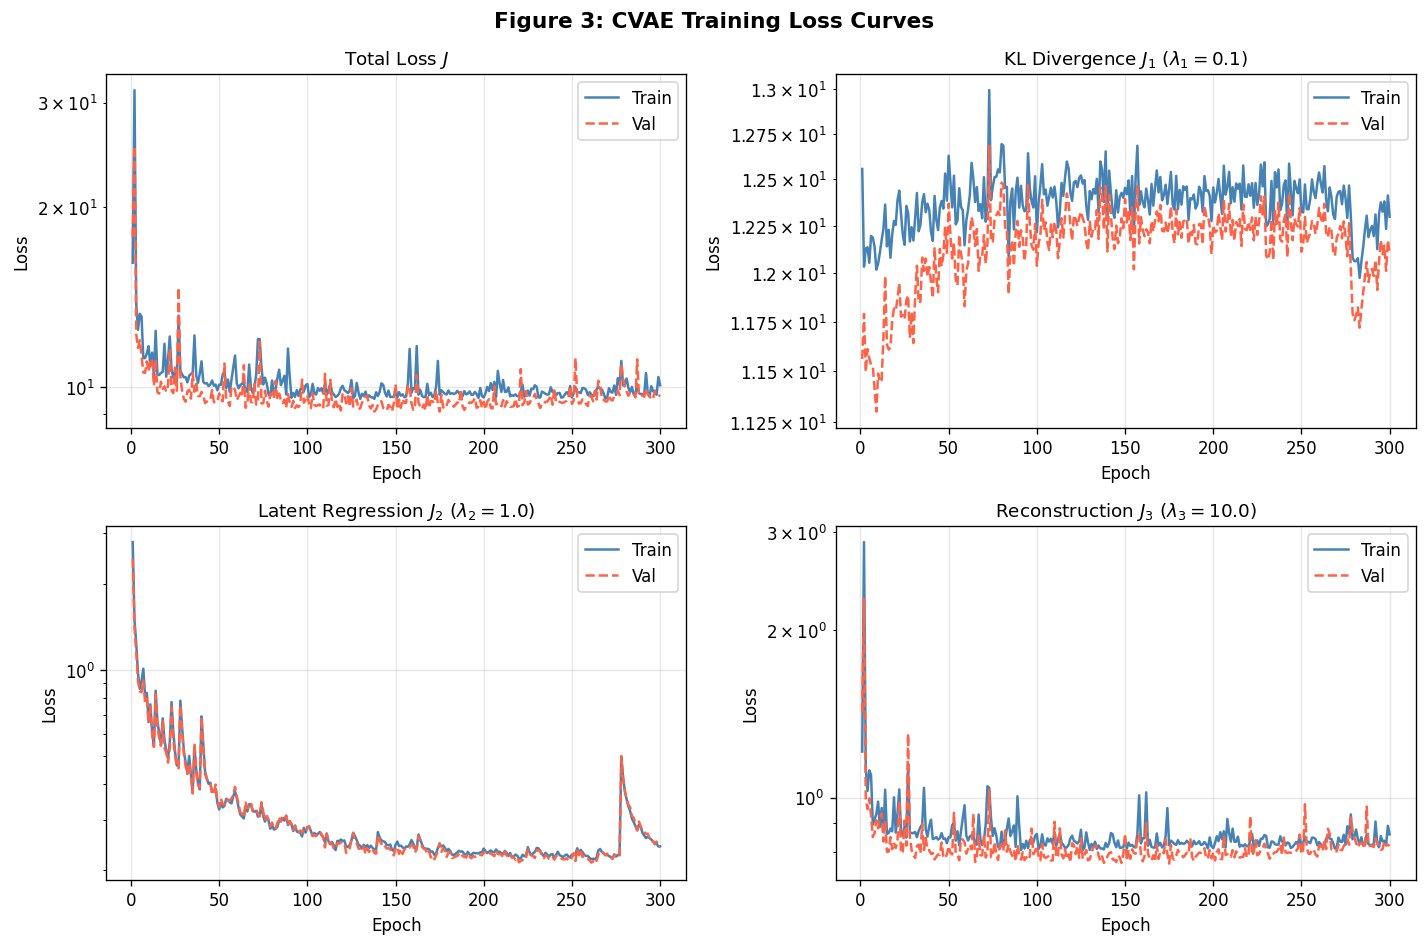

Best epoch: 175 / 300
Best val total_loss: 9.0855
Best val recon_loss: 0.7611


In [37]:
# --- Update Callbacks to monitor 'val_total_loss' ---
cb_list = [
    callbacks.EarlyStopping(monitor='val_total_loss', patience=30, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_total_loss', factor=0.5, patience=15),
    callbacks.ModelCheckpoint('models/cvae_best.weights.h5', monitor='val_total_loss', save_best_only=True)
]

# --- Corrected Plotting Code ---
import matplotlib.pyplot as plt
import numpy as np

hist = history.history
epochs_ran = range(1, len(hist['total_loss']) + 1)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

loss_pairs = [
    ('total_loss', 'Total Loss $J$'),
    ('kl_loss',    'KL Divergence $J_1$ ($\\lambda_1=0.1$)'),
    ('lat_loss',   'Latent Regression $J_2$ ($\\lambda_2=1.0$)'),
    ('recon_loss', 'Reconstruction $J_3$ ($\\lambda_3=10.0$)'),
]

for ax, (key, title) in zip(axes.flat, loss_pairs):
    ax.plot(epochs_ran, hist[key], color='steelblue', label='Train', linewidth=1.5)
    ax.plot(epochs_ran, hist[f'val_{key}'], color='tomato',
            linestyle='--', label='Val', linewidth=1.5)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.set_title(title); ax.legend()
    ax.set_yscale('log')

fig.suptitle('Figure 3: CVAE Training Loss Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Print stats
best_epoch = np.argmin(hist['val_total_loss']) + 1
print(f"Best epoch: {best_epoch} / {len(epochs_ran)}")
print(f"Best val total_loss: {min(hist['val_total_loss']):.4f}")
print(f"Best val recon_loss: {min(hist['val_recon_loss']):.4f}")

## Cell 10 — Latent Space Analysis

After training, we extract the latent representations ($\mu_z$) for all records and:
1. **Verify correlation** between the 3 PCs (should be near zero — they represent orthogonal features)
2. **Visualise dependence** of PCs on seismological parameters ($M_w$, $R_{JB}$, $V_{s30}$, Depth)
3. **Compute variance** explained by each PC (for comparison with NLPCA)

In [38]:
# ── Extract latent means for full dataset ─────────────────────────────────────
print("Extracting latent representations for all records...")
z_mean_all, z_logvar_all, z_sample_all = encoder.predict(
    [X_scaled, C_scaled], batch_size=256, verbose=0
)
# z_mean_all shape: (N, LATENT_DIM) = (N, 3)

# ── PC correlation ────────────────────────────────────────────────────────────
corr_pcs = np.corrcoef(z_mean_all.T)
print("\nCorrelation between 3 Latent PCs (z_mean):")
print(pd.DataFrame(corr_pcs,
                   index=['PC1','PC2','PC3'],
                   columns=['PC1','PC2','PC3']).round(4).to_string())

# ── Variance of each PC ───────────────────────────────────────────────────────
pc_var = np.var(z_mean_all, axis=0)
pc_var_pct = 100 * pc_var / pc_var.sum()
print(f"\nVariance of PCs: PC1={pc_var_pct[0]:.1f}%, PC2={pc_var_pct[1]:.1f}%, PC3={pc_var_pct[2]:.1f}%")

# ── Pearson correlation of PCs with seismological parameters ──────────────────
param_vals = {
    'Mw': MW_ALL, 'RJB': RJB_ALL,
    'Vs30': VS30_ALL, 'Depth': DEPTH_ALL
}
print("\nCorrelation of PCs with seismological parameters:")
print(f"{'Param':<10}", end='')
for j in range(LATENT_DIM):
    print(f"  PC{j+1}  ", end='')
print()
for pname, pvals in param_vals.items():
    print(f"{pname:<10}", end='')
    for j in range(LATENT_DIM):
        r, _ = stats.pearsonr(pvals, z_mean_all[:, j])
        print(f" {r:+.3f} ", end='')
    print()

Extracting latent representations for all records...

Correlation between 3 Latent PCs (z_mean):
        PC1     PC2     PC3
PC1  1.0000 -0.3626 -0.1802
PC2 -0.3626  1.0000  0.0755
PC3 -0.1802  0.0755  1.0000

Variance of PCs: PC1=55.3%, PC2=25.1%, PC3=19.6%

Correlation of PCs with seismological parameters:
Param       PC1    PC2    PC3  
Mw         +0.600  -0.584  -0.246 
RJB        -0.741  +0.134  +0.145 
Vs30       -0.325  +0.274  -0.127 
Depth      -0.198  +0.223  +0.008 


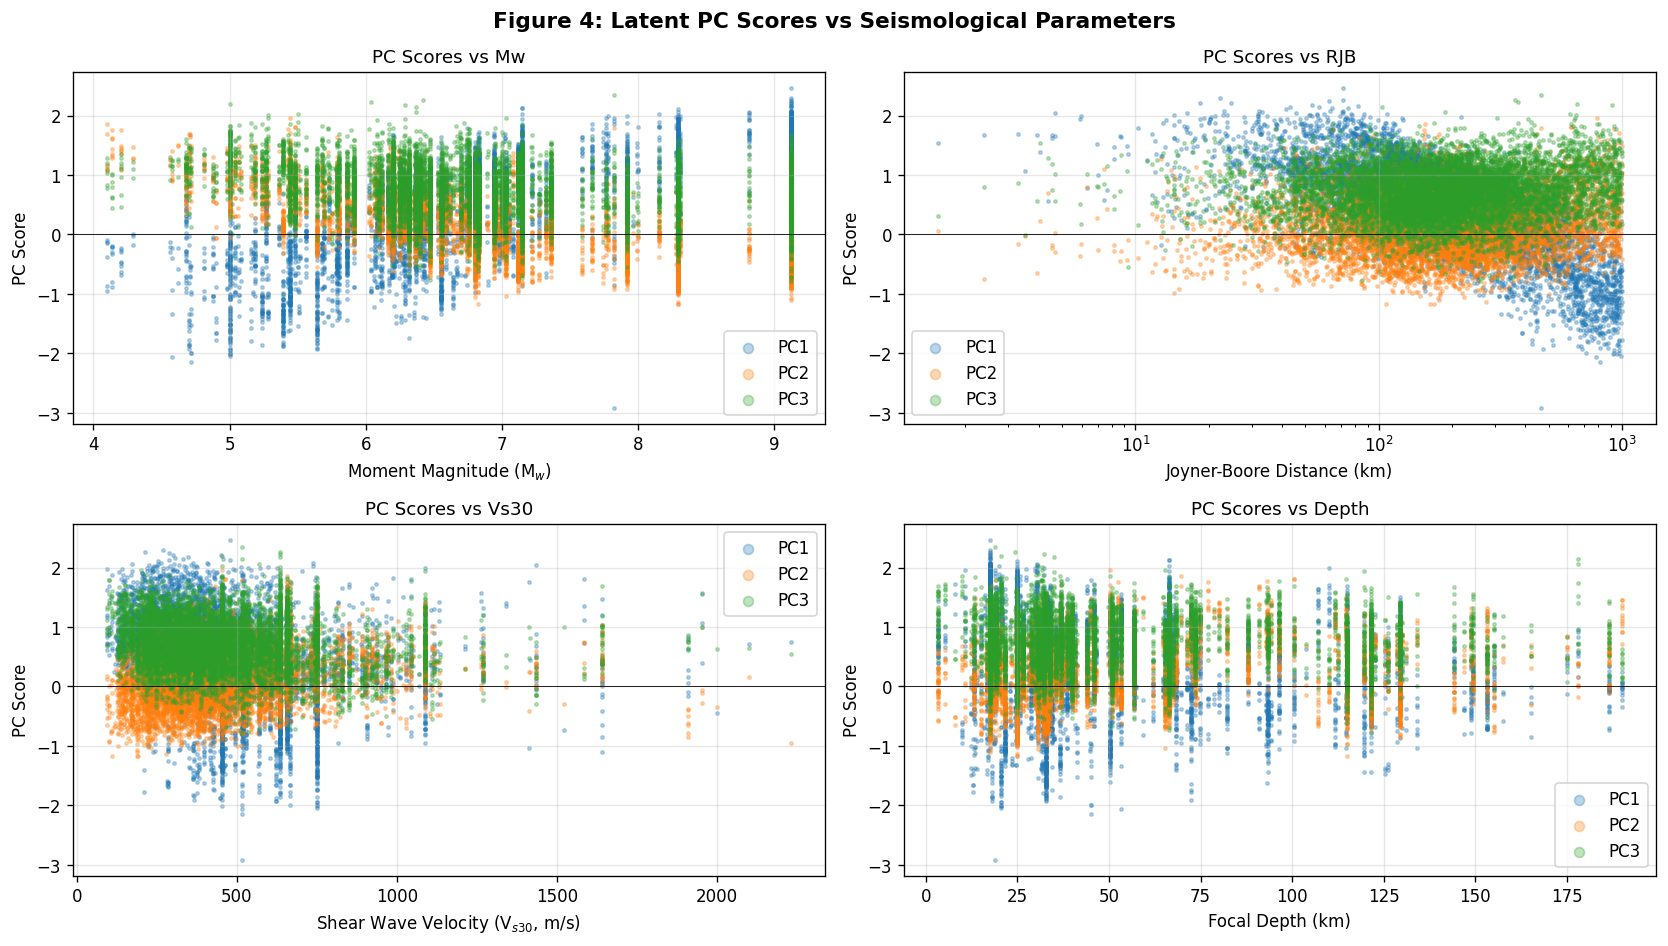

Figure 4 saved.


In [39]:
# ── Figure 4: PC scores vs seismological parameters ───────────────────────────
COLORS_PC = ['#1f77b4', '#ff7f0e', '#2ca02c']

param_plot = [
    ('Mw',    MW_ALL,   'Moment Magnitude (M$_w$)'),
    ('RJB',   RJB_ALL,  'Joyner-Boore Distance (km)'),
    ('Vs30',  VS30_ALL, 'Shear Wave Velocity (V$_{s30}$, m/s)'),
    ('Depth', DEPTH_ALL,'Focal Depth (km)'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, (pname, pvals, xlabel) in zip(axes.flat, param_plot):
    for j in range(LATENT_DIM):
        ax.scatter(pvals, z_mean_all[:, j],
                   s=4, alpha=0.3, color=COLORS_PC[j], label=f'PC{j+1}')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('PC Score')
    ax.set_title(f'PC Scores vs {pname}')
    if pname == 'RJB':
        ax.set_xscale('log')
    ax.legend(markerscale=3)
    ax.axhline(0, color='k', linewidth=0.5)

fig.suptitle('Figure 4: Latent PC Scores vs Seismological Parameters',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fig4_pc_vs_params.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 4 saved.")

## Cell 11 — ANN for Predicting Latent Space (μ, σ) from Conditions

The CVAE encoder takes both $X$ (spectra) **and** $C$ (conditions) as input — so we cannot use it for prediction on new earthquake scenarios where we only have $C$.

The solution: **train a separate ANN** that maps $C \to (\mu_z, \sigma_z)$ — the mean and standard deviation of the latent space, as learned by the CVAE encoder.

### ANN Architecture (Section 6.3 of paper):
```
C (6) → Dense(6, ELU) → Dense(3, ELU) → [mean_z (3), std_z (3)]
```
Two hidden layers with 6 and 3 neurons respectively (minimal, to avoid overfitting on the learned latent space).

In [40]:
def build_latent_ann(n_cond, latent_dim, hidden_units=(6, 3), lr=0.001):
    """
    ANN to predict latent mean and log_variance from seismological conditions C.
    
    Following paper Section 6.3:
    - 2 hidden layers (6 and 3 neurons)
    - ELU activations
    - ADAM optimizer, MSE loss
    - Outputs: [μ_PC1, μ_PC2, μ_PC3, log_σ²_PC1, log_σ²_PC2, log_σ²_PC3]
    """
    inp = Input(shape=(n_cond,), name='C_input')
    h = inp
    for i, units in enumerate(hidden_units):
        h = layers.Dense(units, activation='elu', name=f'ANN_h{i+1}')(h)

    # Mean output head
    mean_out = layers.Dense(latent_dim, name='mu_z')(h)
    # Log-variance output head  
    logvar_out = layers.Dense(latent_dim, name='logvar_z')(h)
    
    # Concatenate both heads
    combined = layers.Concatenate(name='mu_logvar')([mean_out, logvar_out])
    
    model = Model(inp, combined, name='Latent_ANN')
    model.compile(optimizer=Adam(lr), loss='mse')
    return model


# ── Prepare ANN targets: [z_mean_all | z_logvar_all] ─────────────────────────
latent_targets = np.concatenate([z_mean_all, z_logvar_all], axis=1)  # (N, 6)

# Normalize targets for stable training
scaler_latent = StandardScaler()
latent_targets_sc = scaler_latent.fit_transform(latent_targets).astype(np.float32)

# Split matching the CVAE split
lt_tr = latent_targets_sc[idx_train]
lt_va = latent_targets_sc[idx_val]
lt_te = latent_targets_sc[idx_test]

# ── Build and train ANN ───────────────────────────────────────────────────────
latent_ann = build_latent_ann(N_COND, LATENT_DIM)
latent_ann.summary()

cb_ann = [
    callbacks.EarlyStopping(monitor='val_loss', patience=40,
                             restore_best_weights=True, verbose=0),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                 patience=20, min_lr=1e-6, verbose=0),
]

hist_ann = latent_ann.fit(
    C_tr, lt_tr,
    validation_data=(C_va, lt_va),
    epochs=500,
    batch_size=32,
    callbacks=cb_ann,
    verbose=0,
)

# Evaluate
ann_pred_te = latent_ann.predict(C_te, verbose=0)
ann_r2 = r2_score(lt_te, ann_pred_te)
print(f"ANN R² on test set: {ann_r2:.4f}")
print(f"ANN training epochs: {len(hist_ann.history['loss'])}")
print("Latent ANN training complete.")

Model: "Latent_ANN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ C_input             │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ANN_h1 (Dense)      │ (None, 6)         │         42 │ C_input[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ANN_h2 (Dense)      │ (None, 3)         │         21 │ ANN_h1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mu_z (Dense)        │ (None, 3)         │         12 │ ANN_h2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ logvar_z (Dense)    │ (None, 3)         │         12 │ ANN_h2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mu_logvar           │ (None, 6)         │          0 │ mu_z[0][0],       │
│ (Concatenate)       │                   │            │ logvar_z[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 87 (348.00 B)

 Trainable params: 87 (348.00 B)

 Non-trainable params: 0 (0.00 B)

ANN R² on test set: 0.4213
ANN training epochs: 500
Latent ANN training complete.


## Cell 12 — Reconstruction Evaluation: CVAE vs Recorded

We evaluate the model by:
1. **Using the CVAE directly** (encoder → latent → decoder) — this is the best-case reconstruction
2. **Using ANN → decoder** — this is the actual prediction pipeline for new scenarios

Performance metrics in log space:
- $R^2$: coefficient of determination (closer to 1 = better)
- RMSE: root mean squared error
- MAE: mean absolute error
- MAPE: mean absolute percentage error

In [41]:
# ── CVAE reconstruction (encoder → latent → decoder) ─────────────────────────
print("Evaluating CVAE reconstruction...")
z_mean_te, z_logvar_te, _ = encoder.predict([X_te, C_te], batch_size=256, verbose=0)
X_te_hat_cvae = decoder.predict([z_mean_te, C_te], batch_size=256, verbose=0)

# Back-transform: scaled → ln(PSA) → PSA
X_te_ln   = scaler_X.inverse_transform(X_te)           # ln(PSA) actual
X_te_hat_ln = scaler_X.inverse_transform(X_te_hat_cvae) # ln(PSA) predicted

# ── ANN → decoder pipeline ────────────────────────────────────────────────────
print("Evaluating ANN → CVAE decoder pipeline...")
ann_pred_te_sc = latent_ann.predict(C_te, verbose=0)
ann_pred_te_orig = scaler_latent.inverse_transform(ann_pred_te_sc)
ann_mu_te = ann_pred_te_orig[:, :LATENT_DIM].astype(np.float32)
X_te_hat_ann = decoder.predict([ann_mu_te, C_te], batch_size=256, verbose=0)
X_te_hat_ann_ln = scaler_X.inverse_transform(X_te_hat_ann)

# ── Metrics function ──────────────────────────────────────────────────────────
def compute_metrics(actual, predicted, name=''):
    flat_a = actual.flatten()
    flat_p = predicted.flatten()
    r2   = r2_score(flat_a, flat_p)
    rmse = np.sqrt(mean_squared_error(flat_a, flat_p))
    mae  = mean_absolute_error(flat_a, flat_p)
    mape = np.mean(np.abs((flat_a - flat_p) / (np.abs(flat_a) + 1e-8))) * 100
    print(f"{name:30s}  R²={r2:.4f}  RMSE={rmse:.4f}  MAE={mae:.4f}  MAPE={mape:.2f}%")
    return dict(r2=r2, rmse=rmse, mae=mae, mape=mape)

print("\nPerformance Metrics (ln PSA space):")
print("-" * 70)
m_cvae = compute_metrics(X_te_ln, X_te_hat_ln,     'CVAE (encoder→decoder)')
m_ann  = compute_metrics(X_te_ln, X_te_hat_ann_ln, 'ANN → CVAE decoder')

Evaluating CVAE reconstruction...
Evaluating ANN → CVAE decoder pipeline...

Performance Metrics (ln PSA space):
----------------------------------------------------------------------
CVAE (encoder→decoder)          R²=0.9936  RMSE=0.2128  MAE=0.1596  MAPE=26.79%
ANN → CVAE decoder              R²=0.8864  RMSE=0.8978  MAE=0.6990  MAPE=127.50%


## Cell 13 — Figure 5: CVAE Period-by-Period Performance

Evaluating $R^2$ and RMSE **at each spectral period** shows whether the model captures short-period, intermediate, and long-period spectral shapes equally well.

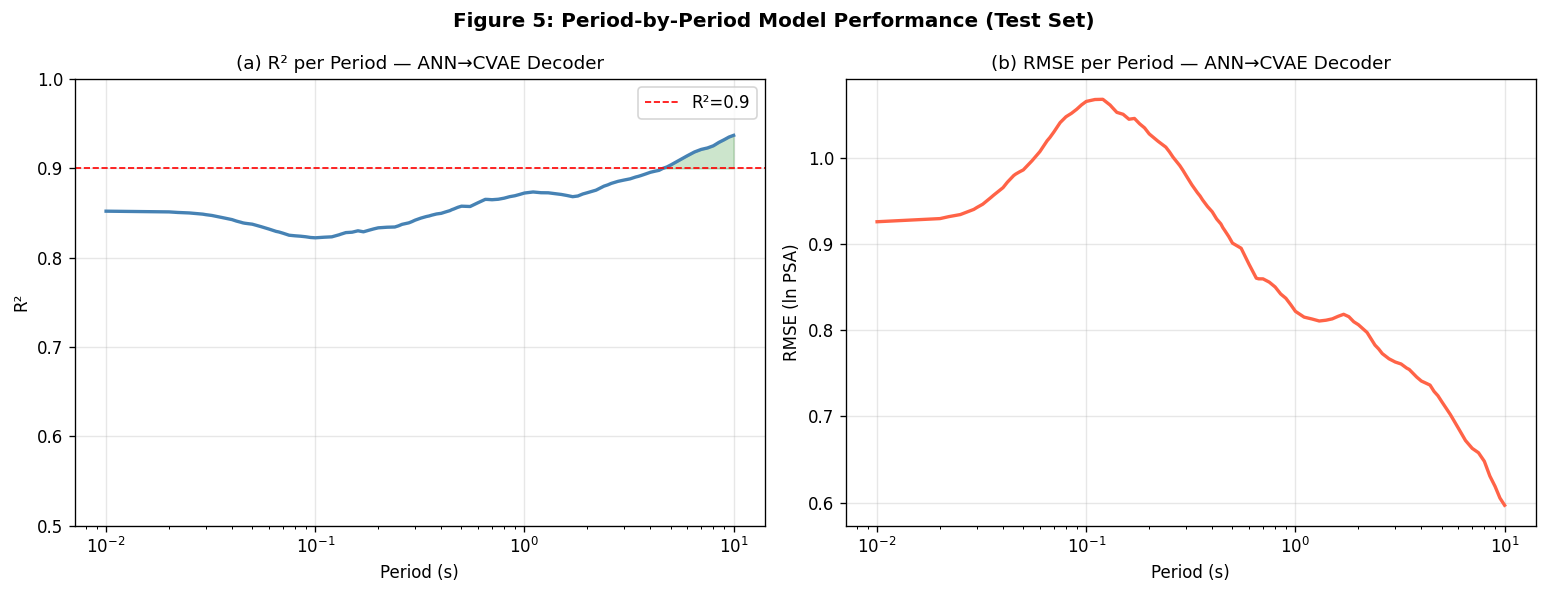

Mean R²   : 0.8611
Mean RMSE : 0.8886
Periods with R² > 0.9: 13 / 105


In [42]:
# Period-by-period metrics
r2_per_T   = [r2_score(X_te_ln[:, t], X_te_hat_ann_ln[:, t]) for t in range(N_PERIODS)]
rmse_per_T = [np.sqrt(mean_squared_error(X_te_ln[:, t], X_te_hat_ann_ln[:, t])) for t in range(N_PERIODS)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.semilogx(PERIOD_VALUES, r2_per_T, color='steelblue', linewidth=2)
ax1.axhline(0.9, color='r', linestyle='--', linewidth=1, label='R²=0.9')
ax1.fill_between(PERIOD_VALUES, r2_per_T, 0.9, where=[r >= 0.9 for r in r2_per_T],
                  alpha=0.2, color='green')
ax1.set_xlabel('Period (s)'); ax1.set_ylabel('R²'); ax1.set_title('(a) R² per Period — ANN→CVAE Decoder')
ax1.legend(); ax1.set_ylim([0.5, 1.0])

ax2.semilogx(PERIOD_VALUES, rmse_per_T, color='tomato', linewidth=2)
ax2.set_xlabel('Period (s)'); ax2.set_ylabel('RMSE (ln PSA)')
ax2.set_title('(b) RMSE per Period — ANN→CVAE Decoder')

fig.suptitle('Figure 5: Period-by-Period Model Performance (Test Set)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fig5_per_period_performance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Mean R²   : {np.mean(r2_per_T):.4f}")
print(f"Mean RMSE : {np.mean(rmse_per_T):.4f}")
print(f"Periods with R² > 0.9: {sum(r >= 0.9 for r in r2_per_T)} / {N_PERIODS}")

## Cell 14 — Figure 6: Sample Spectrum Comparisons (Recorded vs Reconstructed)

Visual comparison for randomly selected ground motion records — the key qualitative check.

Each panel shows:
- **Black**: Recorded spectrum
- **Red dashed**: ANN + CVAE decoder (mean prediction)
- **Cyan shaded**: 100-sample CVAE ensemble (captures epistemic uncertainty)

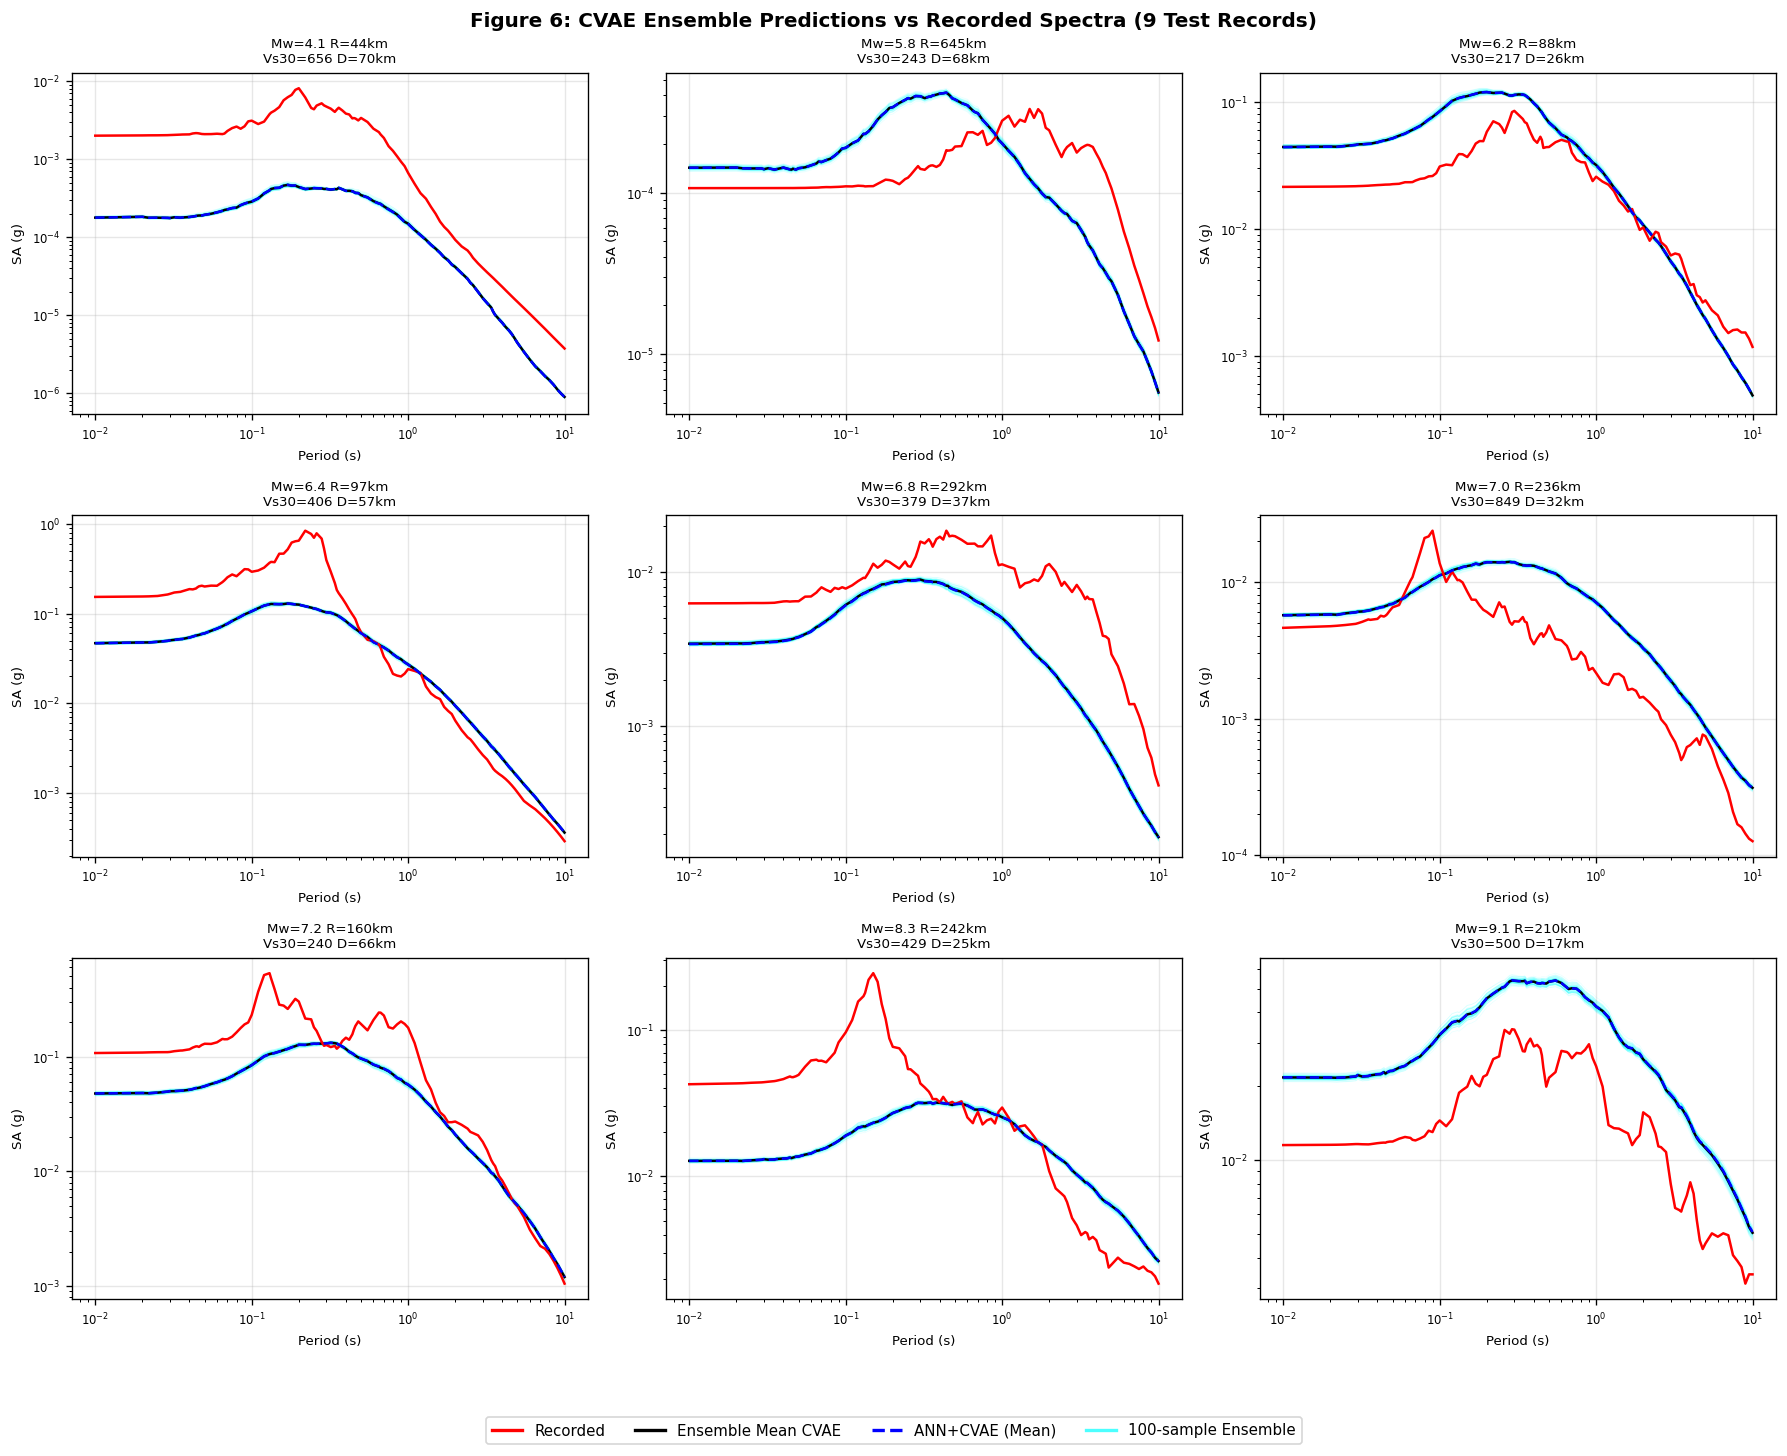

Figure 6 saved.


In [43]:
N_SAMPLES_ENSEMBLE = 100
N_SHOW = 9   # panels in the figure

# Pick representative samples from test set (spread across Mw range)
mw_te = MW_ALL[idx_test]
sort_idx = np.argsort(mw_te)
show_idx = sort_idx[np.round(np.linspace(0, len(sort_idx)-1, N_SHOW)).astype(int)]

fig, axes = plt.subplots(3, 3, figsize=(15, 12), sharey=False)

for ax, si in zip(axes.flat, show_idx):
    # Actual recorded spectrum
    actual_ln = X_te_ln[si, :]           # ln(PSA) actual
    actual_psa = np.exp(actual_ln)       # PSA in g

    # ANN → decoder mean prediction
    ann_pred_si = ann_mu_te[si:si+1]    # (1, 3)
    c_si        = C_te[si:si+1]         # (1, 6)
    pred_sc     = decoder.predict([ann_pred_si, c_si], verbose=0)  # scaled
    pred_ln     = scaler_X.inverse_transform(pred_sc)[0]
    pred_psa    = np.exp(pred_ln)

    # CVAE ensemble (sample z from ANN-predicted distribution)
    ann_out_si  = ann_pred_te_orig[si]
    mu_si       = ann_out_si[:LATENT_DIM].astype(np.float32)
    lv_si       = ann_out_si[LATENT_DIM:].astype(np.float32)
    std_si      = np.exp(0.5 * lv_si)
    
    ens_ln = []
    for _ in range(N_SAMPLES_ENSEMBLE):
        z_samp = (mu_si + std_si * np.random.randn(LATENT_DIM)).reshape(1, -1).astype(np.float32)
        x_sc_s = decoder.predict([z_samp, c_si], verbose=0)
        ens_ln.append(scaler_X.inverse_transform(x_sc_s)[0])
    ens_ln  = np.array(ens_ln)
    ens_psa = np.exp(ens_ln)

    # Metadata for title
    rec_idx  = idx_test[si]
    mw_s     = MW_ALL[rec_idx]
    rjb_s    = RJB_ALL[rec_idx]
    vs30_s   = VS30_ALL[rec_idx]
    depth_s  = DEPTH_ALL[rec_idx]

    # Plot ensemble
    for e in ens_psa:
        ax.loglog(PERIOD_VALUES, e, color='cyan', alpha=0.08, linewidth=0.5)
    ax.loglog(PERIOD_VALUES, np.exp(np.mean(ens_ln, axis=0)),
               color='black', linewidth=1.5, label='Ens. Mean')
    ax.loglog(PERIOD_VALUES, actual_psa, color='red', linewidth=1.5,
               linestyle='-', label='Recorded')
    ax.loglog(PERIOD_VALUES, pred_psa, color='blue', linewidth=1.5,
               linestyle='--', label='ANN+CVAE')

    ax.set_title(f'Mw={mw_s:.1f} R={rjb_s:.0f}km\nVs30={vs30_s:.0f} D={depth_s:.0f}km',
                  fontsize=8)
    ax.set_xlabel('Period (s)', fontsize=8)
    ax.set_ylabel('SA (g)', fontsize=8)
    ax.tick_params(labelsize=7)

# Unified legend
from matplotlib.lines import Line2D
legend_elems = [
    Line2D([0],[0], color='red',   lw=2, label='Recorded'),
    Line2D([0],[0], color='black', lw=2, label='Ensemble Mean CVAE'),
    Line2D([0],[0], color='blue',  lw=2, linestyle='--', label='ANN+CVAE (Mean)'),
    Line2D([0],[0], color='cyan',  lw=2, alpha=0.7, label=f'{N_SAMPLES_ENSEMBLE}-sample Ensemble'),
]
fig.legend(handles=legend_elems, loc='lower center', ncol=4,
           bbox_to_anchor=(0.5, -0.02), fontsize=9)

fig.suptitle('Figure 6: CVAE Ensemble Predictions vs Recorded Spectra (9 Test Records)',
             fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig('figures/fig6_sample_comparisons.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 6 saved.")

## Cell 15 — Figure 7: Seismic Physics Checks (Variation with Seismological Parameters)

A GMM must obey **seismological physics**:
1. **Distance scaling**: SA decreases with increasing $R_{JB}$ (attenuation)
2. **Magnitude scaling**: SA increases with $M_w$, with saturation at high magnitudes
3. **Depth scaling**: Deeper sources → different path
4. **Site effects**: Lower $V_{s30}$ → higher SA (soil amplification)

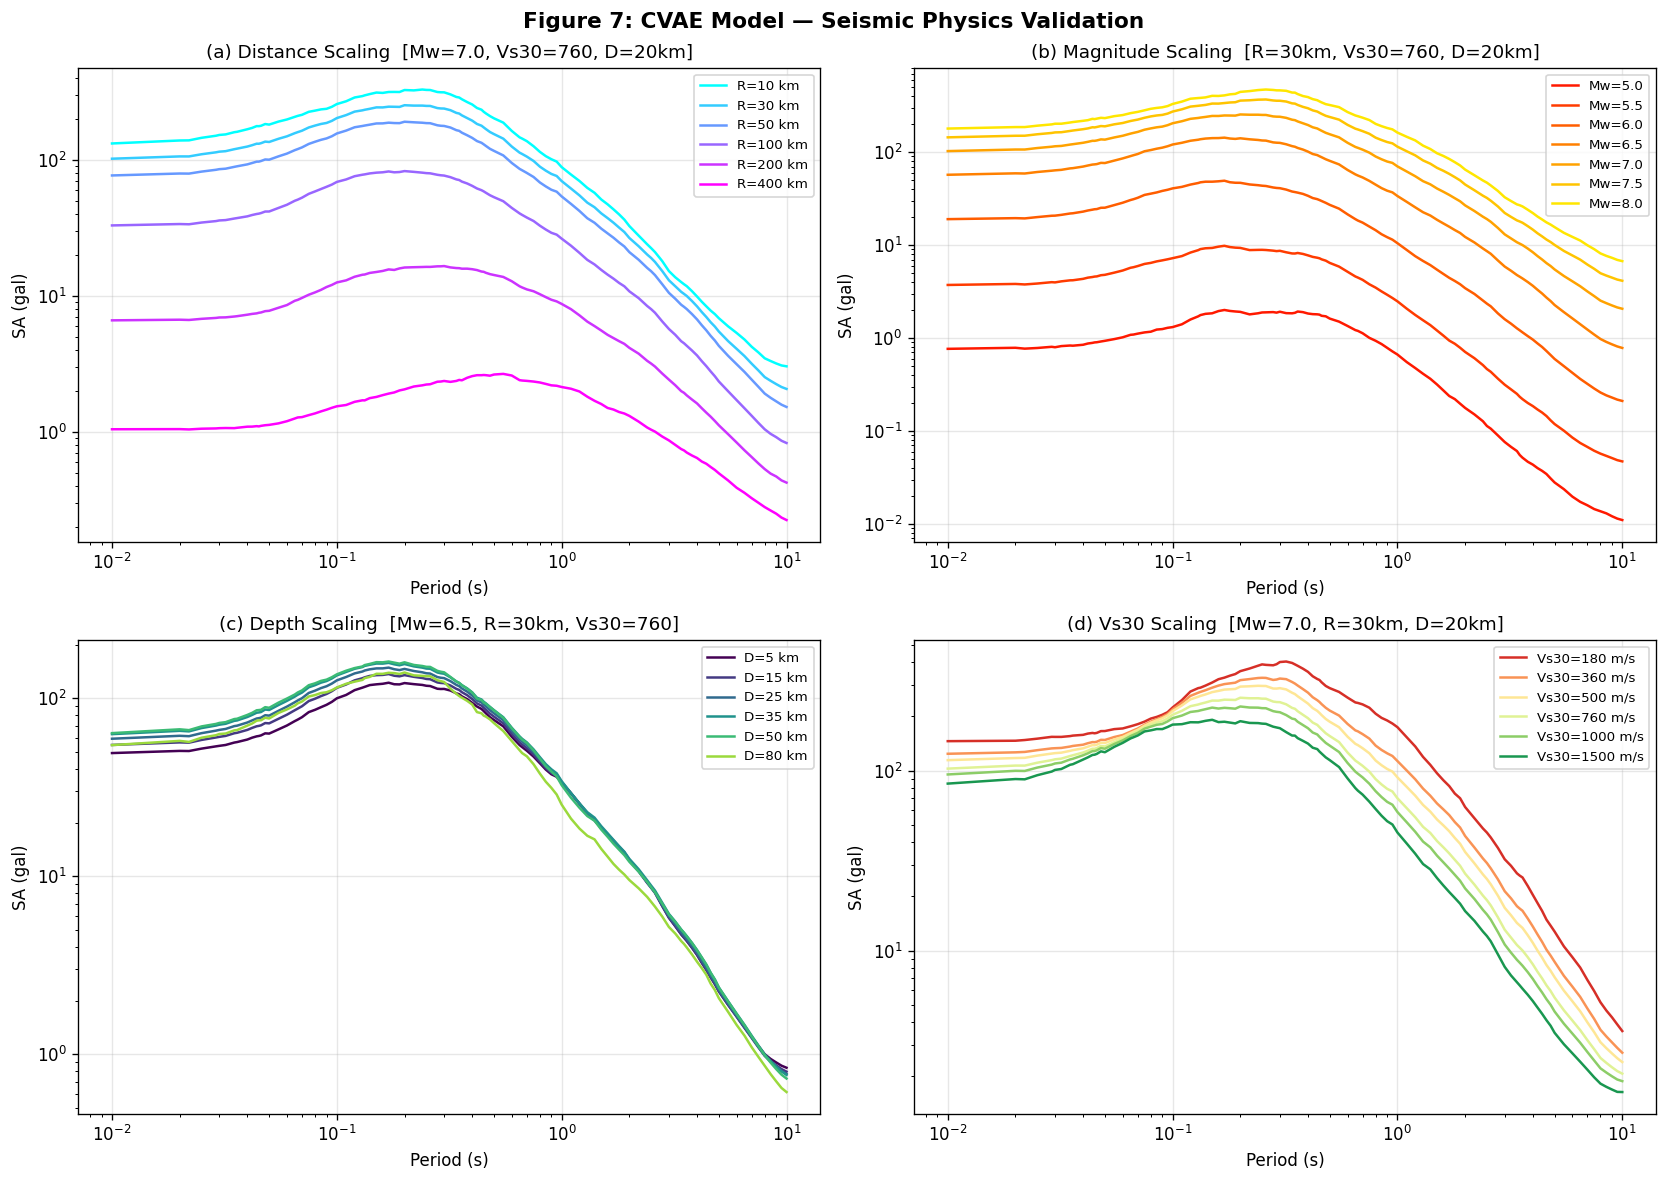

Figure 7 saved.


In [44]:
def predict_spectrum(mw, rjb, vs30, depth, fm=1, n_ensemble=None):
    """
    Predict response spectrum for given seismological conditions.
    
    Parameters
    ----------
    mw, rjb, vs30, depth : float — seismological parameters
    fm : int — fault mechanism (1=Interface, 2=Intraslab)
    n_ensemble : int or None — if given, return ensemble of that size
    
    Returns
    -------
    SA in cm/s² (or array if ensemble)
    """
    log_rjb  = np.log(max(rjb, 0.01))
    log_vs30 = np.log(vs30)
    c_raw    = np.array([[mw, rjb, log_rjb, log_vs30, depth, fm]], dtype=np.float32)
    c_sc     = scaler_C.transform(c_raw).astype(np.float32)

    ann_out  = latent_ann.predict(c_sc, verbose=0)
    ann_orig = scaler_latent.inverse_transform(ann_out)
    mu_z     = ann_orig[:, :LATENT_DIM].astype(np.float32)
    lv_z     = ann_orig[:, LATENT_DIM:].astype(np.float32)
    std_z    = np.exp(0.5 * lv_z)

    if n_ensemble is None:
        x_sc = decoder.predict([mu_z, c_sc], verbose=0)
        ln_psa = scaler_X.inverse_transform(x_sc)[0]
        return np.exp(ln_psa) * 981  # g → cm/s²  (gal)
    else:
        spectra = []
        for _ in range(n_ensemble):
            z_s = (mu_z + std_z * np.random.randn(1, LATENT_DIM)).astype(np.float32)
            x_s = decoder.predict([z_s, c_sc], verbose=0)
            ln_s = scaler_X.inverse_transform(x_s)[0]
            spectra.append(np.exp(ln_s) * 981)
        return np.array(spectra)  # (n_ensemble, N_PERIODS)


fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── (a) Distance scaling ──────────────────────────────────────────────────────
ax = axes[0, 0]
R_vals  = [10, 30, 50, 100, 200, 400]
colors  = plt.cm.cool(np.linspace(0, 1, len(R_vals)))
for r, c in zip(R_vals, colors):
    sa = predict_spectrum(mw=7.0, rjb=r, vs30=760, depth=20, fm=1)
    ax.loglog(PERIOD_VALUES, sa, color=c, linewidth=1.5, label=f'R={r} km')
ax.set_xlabel('Period (s)'); ax.set_ylabel('SA (gal)')
ax.set_title('(a) Distance Scaling  [Mw=7.0, Vs30=760, D=20km]')
ax.legend(fontsize=8)

# ── (b) Magnitude scaling ─────────────────────────────────────────────────────
ax = axes[0, 1]
Mw_vals = [5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0]
colors  = plt.cm.autumn(np.linspace(0.1, 0.9, len(Mw_vals)))
for m, c in zip(Mw_vals, colors):
    sa = predict_spectrum(mw=m, rjb=30, vs30=760, depth=20, fm=1)
    ax.loglog(PERIOD_VALUES, sa, color=c, linewidth=1.5, label=f'Mw={m}')
ax.set_xlabel('Period (s)'); ax.set_ylabel('SA (gal)')
ax.set_title('(b) Magnitude Scaling  [R=30km, Vs30=760, D=20km]')
ax.legend(fontsize=8)

# ── (c) Depth scaling ─────────────────────────────────────────────────────────
ax = axes[1, 0]
D_vals = [5, 15, 25, 35, 50, 80]
colors = plt.cm.viridis(np.linspace(0, 0.85, len(D_vals)))
for d, c in zip(D_vals, colors):
    sa = predict_spectrum(mw=6.5, rjb=30, vs30=760, depth=d, fm=1)
    ax.loglog(PERIOD_VALUES, sa, color=c, linewidth=1.5, label=f'D={d} km')
ax.set_xlabel('Period (s)'); ax.set_ylabel('SA (gal)')
ax.set_title('(c) Depth Scaling  [Mw=6.5, R=30km, Vs30=760]')
ax.legend(fontsize=8)

# ── (d) Site condition (Vs30) scaling ─────────────────────────────────────────
ax = axes[1, 1]
Vs_vals = [180, 360, 500, 760, 1000, 1500]
colors  = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(Vs_vals)))
for v, c in zip(Vs_vals, colors):
    sa = predict_spectrum(mw=7.0, rjb=30, vs30=v, depth=20, fm=1)
    ax.loglog(PERIOD_VALUES, sa, color=c, linewidth=1.5, label=f'Vs30={v} m/s')
ax.set_xlabel('Period (s)'); ax.set_ylabel('SA (gal)')
ax.set_title('(d) Vs30 Scaling  [Mw=7.0, R=30km, D=20km]')
ax.legend(fontsize=8)

fig.suptitle('Figure 7: CVAE Model — Seismic Physics Validation',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fig7_physics_checks.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 7 saved.")

## Cell 16 — Figure 8: Epistemic Uncertainty Quantification

One of the main advantages of CVAE over standard ANN/BNN is **ensemble generation** — by sampling $z$ from the learned latent distribution, we get a set of plausible spectra for any given earthquake scenario. The spread of this ensemble captures **epistemic uncertainty** (model uncertainty).

Epistemic standard deviation per ground motion:
$$\sigma^2_{\text{epistemic}} = \frac{1}{T}\sum_{s=1}^{n} \sigma^2_{n-\text{epistemic}}$$

Note: Epistemic σ (model uncertainty) is typically much **smaller** than aleatory σ (natural variability), which is quantified through mixed-effects regression.

In [45]:
N_ENS = 100  # ensemble size per record (m = 100, as in paper)

# Compute epistemic uncertainty for a subset of test records
N_EPI = min(300, len(idx_test))  # use 300 records for speed
epi_std_per_rec = []  # epistemic std for each record (in log10 space)

print(f"Computing epistemic uncertainty for {N_EPI} test records ({N_ENS} ensemble each)...")

for i in range(N_EPI):
    c_si = C_te[i:i+1]
    ao   = scaler_latent.inverse_transform(latent_ann.predict(c_si, verbose=0))
    mu_s = ao[:, :LATENT_DIM].astype(np.float32)
    lv_s = ao[:, LATENT_DIM:].astype(np.float32)
    std_s = np.exp(0.5 * lv_s)

    ens_ln10 = []
    for _ in range(N_ENS):
        z_s   = (mu_s + std_s * np.random.randn(1, LATENT_DIM)).astype(np.float32)
        x_s   = decoder.predict([z_s, c_si], verbose=0)
        ln_s  = scaler_X.inverse_transform(x_s)[0]
        ens_ln10.append(ln_s / np.log(10))  # convert to log10

    ens_arr = np.array(ens_ln10)  # (N_ENS, N_PERIODS)
    # Epistemic std = std across ensemble, averaged over periods
    epi_std_per_rec.append(np.std(ens_arr, axis=0).mean())

epi_std_per_rec = np.array(epi_std_per_rec)
print(f"\nMean epistemic σ (log10): {epi_std_per_rec.mean():.4f}")
print(f"Range: [{epi_std_per_rec.min():.4f}, {epi_std_per_rec.max():.4f}]")

# ── Compute period-by-period epistemic std for a fixed scenario ───────────────
mw_ref, rjb_ref, vs30_ref, d_ref = 7.0, 50.0, 760.0, 20.0
log_r_ref  = np.log(rjb_ref)
log_v_ref  = np.log(vs30_ref)
c_ref_raw  = np.array([[mw_ref, rjb_ref, log_r_ref, log_v_ref, d_ref, 1.0]], dtype=np.float32)
c_ref_sc   = scaler_C.transform(c_ref_raw).astype(np.float32)
ao_ref     = scaler_latent.inverse_transform(latent_ann.predict(c_ref_sc, verbose=0))
mu_ref     = ao_ref[:, :LATENT_DIM].astype(np.float32)
lv_ref     = ao_ref[:, LATENT_DIM:].astype(np.float32)
std_ref    = np.exp(0.5 * lv_ref)

ens_ref = []
for _ in range(N_ENS):
    z_r  = (mu_ref + std_ref * np.random.randn(1, LATENT_DIM)).astype(np.float32)
    x_r  = decoder.predict([z_r, c_ref_sc], verbose=0)
    ln_r = scaler_X.inverse_transform(x_r)[0]
    ens_ref.append(ln_r / np.log(10))

ens_ref = np.array(ens_ref)                      # (N_ENS, N_PERIODS)
epi_std_per_T = np.std(ens_ref, axis=0)          # (N_PERIODS,)
epi_med_per_T = np.median(ens_ref, axis=0)
print(f"Period-avg epistemic σ (reference): {epi_std_per_T.mean():.4f} (log10)")

Computing epistemic uncertainty for 300 test records (100 ensemble each)...

Mean epistemic σ (log10): 0.0126
Range: [0.0106, 0.0147]
Period-avg epistemic σ (reference): 0.0121 (log10)


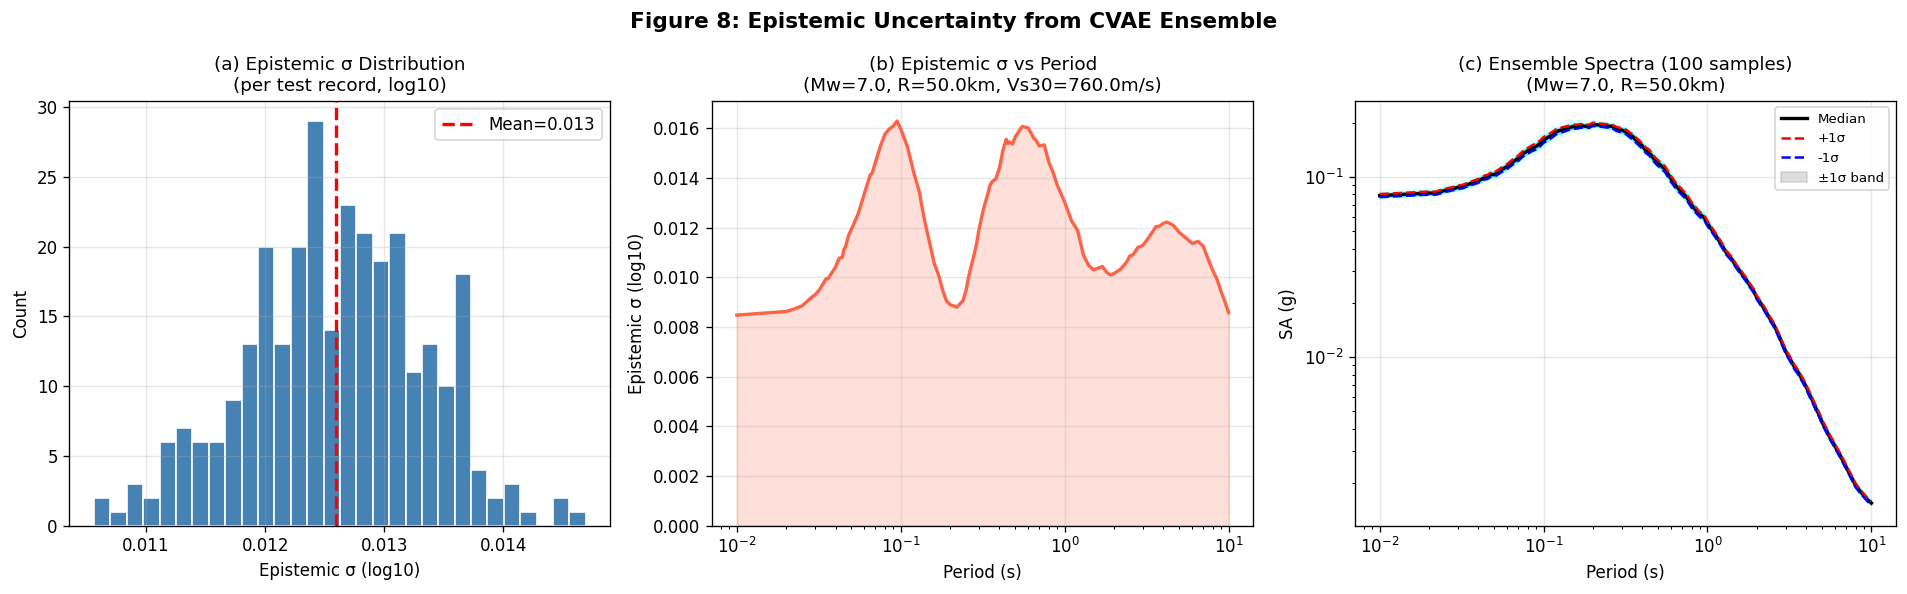

Figure 8 saved.


In [46]:
# ── Figure 8: Epistemic uncertainty plots ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel (a): Histogram of per-record epistemic std
ax = axes[0]
ax.hist(epi_std_per_rec, bins=30, color='steelblue', edgecolor='white')
ax.axvline(epi_std_per_rec.mean(), color='red', linestyle='--',
            linewidth=2, label=f'Mean={epi_std_per_rec.mean():.3f}')
ax.set_xlabel('Epistemic σ (log10)')
ax.set_ylabel('Count')
ax.set_title('(a) Epistemic σ Distribution\n(per test record, log10)')
ax.legend()

# Panel (b): Epistemic std vs period
ax = axes[1]
ax.semilogx(PERIOD_VALUES, epi_std_per_T, color='tomato', linewidth=2)
ax.fill_between(PERIOD_VALUES, 0, epi_std_per_T, alpha=0.2, color='tomato')
ax.set_xlabel('Period (s)')
ax.set_ylabel('Epistemic σ (log10)')
ax.set_title(f'(b) Epistemic σ vs Period\n(Mw={mw_ref}, R={rjb_ref}km, Vs30={vs30_ref}m/s)')
ax.set_ylim(bottom=0)

# Panel (c): Ensemble spread on a spectrum
ax = axes[2]
for e in ens_ref:
    ax.semilogx(PERIOD_VALUES, 10**e, color='cyan', alpha=0.1, linewidth=0.5)
median_sa  = 10**epi_med_per_T
p84_sa     = 10**(epi_med_per_T + epi_std_per_T)
p16_sa     = 10**(epi_med_per_T - epi_std_per_T)
ax.loglog(PERIOD_VALUES, median_sa, 'k-', linewidth=2, label='Median')
ax.loglog(PERIOD_VALUES, p84_sa,    'r--', linewidth=1.5, label='+1σ')
ax.loglog(PERIOD_VALUES, p16_sa,    'b--', linewidth=1.5, label='-1σ')
ax.fill_between(PERIOD_VALUES, p16_sa, p84_sa,
                 alpha=0.25, color='gray', label='±1σ band')
ax.set_xlabel('Period (s)'); ax.set_ylabel('SA (g)')
ax.set_title(f'(c) Ensemble Spectra ({N_ENS} samples)\n(Mw={mw_ref}, R={rjb_ref}km)')
ax.legend(fontsize=8)

fig.suptitle('Figure 8: Epistemic Uncertainty from CVAE Ensemble', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fig8_epistemic_uncertainty.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 8 saved.")

## Cell 17 — Mixed-Effects Residual Analysis & Aleatory Variability

Following the **mixed-effects regression procedure** from Sriwastav et al. (2025) and Abrahamson & Youngs (1992):

$$y_{ij} = f(X_i, \beta) + \Delta_{ij}, \quad \Delta_{ij} \sim N(0, \sigma^2)$$

Residuals are decomposed into:
- **Inter-event** ($\tau$): Event-to-event variability — reflects source uncertainty
- **Intra-event** ($\phi$): Record-to-record within an event — reflects path and site uncertainty

Total aleatory variability: $\sigma_{\text{total}} = \sqrt{\tau^2 + \phi^2}$

In [47]:
# ── Compute residuals for all records ─────────────────────────────────────────
print("Computing total residuals (predicted vs recorded in ln space)...")

# Predict for entire dataset
ann_full   = latent_ann.predict(C_scaled, batch_size=512, verbose=0)
ann_full_o = scaler_latent.inverse_transform(ann_full)
mu_full    = ann_full_o[:, :LATENT_DIM].astype(np.float32)
X_hat_full = decoder.predict([mu_full, C_scaled], batch_size=512, verbose=0)
X_hat_full_ln = scaler_X.inverse_transform(X_hat_full)   # (N, N_PERIODS)
Y_log_orig    = scaler_X.inverse_transform(X_scaled)     # (N, N_PERIODS)

total_resid = Y_log_orig - X_hat_full_ln  # raw residuals in ln space

def mixed_effects_one_period(residuals, event_ids):
    """
    Simple two-step mixed-effects decomposition.
    Returns tau (inter-event), phi (intra-event), sigma_total.
    """
    unique_events = np.unique(event_ids)
    event_means   = {}
    for ev in unique_events:
        mask = event_ids == ev
        event_means[ev] = residuals[mask].mean()

    inter_resid = np.array([event_means[ev] for ev in event_ids])  # between-event
    intra_resid = residuals - inter_resid                          # within-event

    tau = np.std(list(event_means.values()))
    phi = np.std(intra_resid)
    sigma_total = np.sqrt(tau**2 + phi**2)
    return tau, phi, sigma_total, inter_resid, intra_resid

# Compute for each period
print("Running mixed-effects decomposition across all periods...")
tau_arr, phi_arr, sig_arr = [], [], []
for t in range(N_PERIODS):
    tau_t, phi_t, sig_t, _, _ = mixed_effects_one_period(total_resid[:, t], EVENT_IDS)
    tau_arr.append(tau_t); phi_arr.append(phi_t); sig_arr.append(sig_t)

tau_arr = np.array(tau_arr)
phi_arr = np.array(phi_arr)
sig_arr = np.array(sig_arr)

print(f"\nAverage σ_tau (inter-event) : {tau_arr.mean():.4f}")
print(f"Average σ_phi (intra-event) : {phi_arr.mean():.4f}")
print(f"Average σ_total             : {sig_arr.mean():.4f}")

Computing total residuals (predicted vs recorded in ln space)...
Running mixed-effects decomposition across all periods...

Average σ_tau (inter-event) : 0.6793
Average σ_phi (intra-event) : 0.7468
Average σ_total             : 1.0100


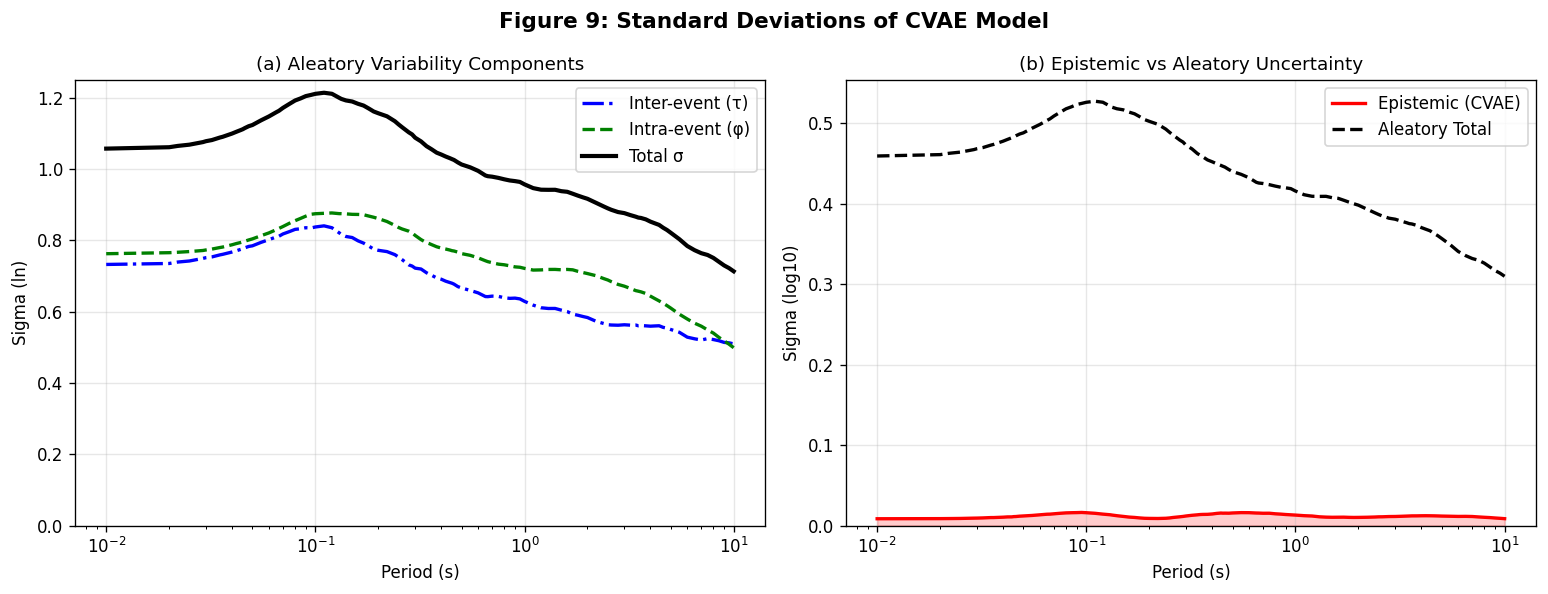

Figure 9 saved.

Epistemic/Aleatory ratio at T=1s: 0.030
(Expected: epistemic << aleatory, ratio << 1)


In [48]:
# ── Figure 9: Standard deviation plots ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel (a): Aleatory components vs period
ax = axes[0]
ax.semilogx(PERIOD_VALUES, tau_arr, 'b-.',  linewidth=2, label='Inter-event (τ)')
ax.semilogx(PERIOD_VALUES, phi_arr, 'g--',  linewidth=2, label='Intra-event (φ)')
ax.semilogx(PERIOD_VALUES, sig_arr, 'k-',   linewidth=2.5, label='Total σ')
ax.set_xlabel('Period (s)'); ax.set_ylabel('Sigma (ln)')
ax.set_title('(a) Aleatory Variability Components')
ax.legend(); ax.set_ylim(bottom=0)

# Panel (b): Epistemic vs aleatory comparison
ax = axes[1]
# Convert aleatory to log10 for comparison
sig_log10 = sig_arr / np.log(10)
ax.semilogx(PERIOD_VALUES, epi_std_per_T,  'r-',  linewidth=2, label='Epistemic (CVAE)')
ax.semilogx(PERIOD_VALUES, sig_log10,       'k--', linewidth=2, label='Aleatory Total')
ax.fill_between(PERIOD_VALUES, epi_std_per_T, alpha=0.2, color='red')
ax.set_xlabel('Period (s)')
ax.set_ylabel('Sigma (log10)')
ax.set_title('(b) Epistemic vs Aleatory Uncertainty')
ax.legend(); ax.set_ylim(bottom=0)

fig.suptitle('Figure 9: Standard Deviations of CVAE Model',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fig9_standard_deviations.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 9 saved.")
print(f"\nEpistemic/Aleatory ratio at T=1s: {epi_std_per_T[68] / (sig_arr[68]/np.log(10)):.3f}")
print("(Expected: epistemic << aleatory, ratio << 1)")

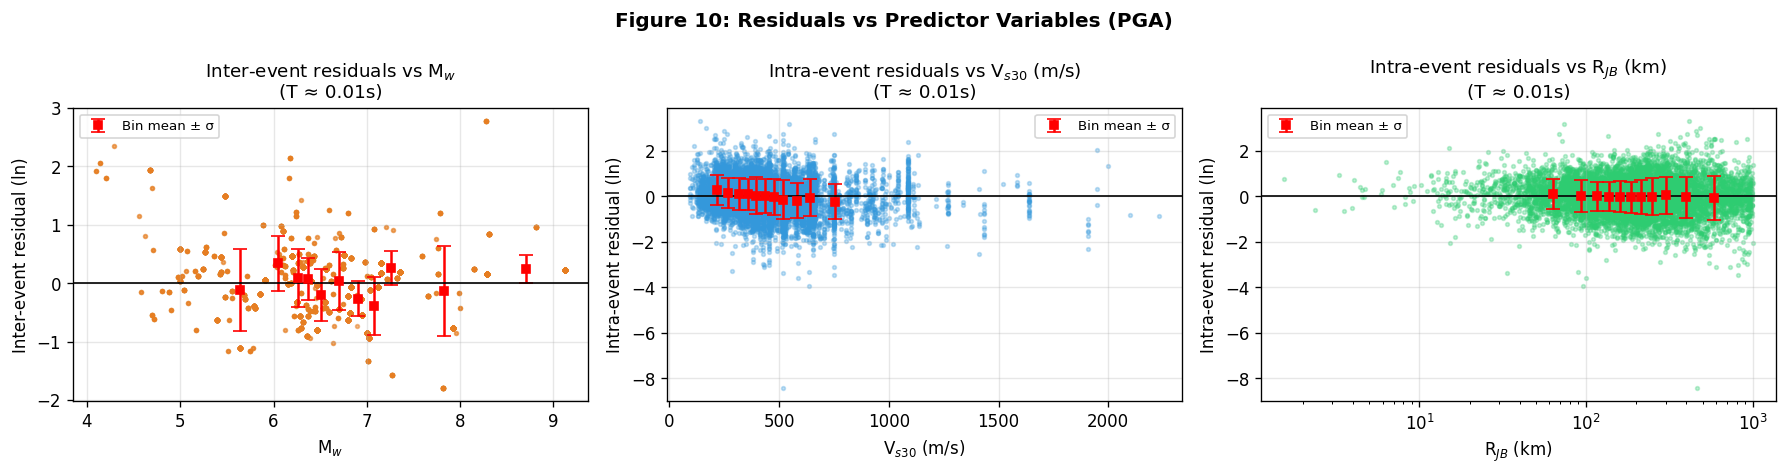

Figure 10 saved.


In [49]:
# ── Figure 10: Residuals vs predictor variables (PGA = T≈0.01s) ──────────────
T_REF_IDX = 0  # T = 0.01 s (approximate PGA)
_, _, _, inter_r, intra_r = mixed_effects_one_period(
    total_resid[:, T_REF_IDX], EVENT_IDS
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

param_resid = [
    (MW_ALL,    inter_r, 'Inter-event', 'M$_w$', '#e67e22'),
    (VS30_ALL,  intra_r, 'Intra-event', 'V$_{s30}$ (m/s)', '#3498db'),
    (RJB_ALL,   intra_r, 'Intra-event', 'R$_{JB}$ (km)', '#2ecc71'),
]

for ax, (xvals, yvals, rtype, xlabel, col) in zip(axes, param_resid):
    ax.scatter(xvals, yvals, s=5, alpha=0.3, color=col)
    # Bin means and ±1σ
    bins = np.percentile(xvals, np.linspace(5, 95, 12))
    bin_means, bin_stds = [], []
    for b0, b1 in zip(bins[:-1], bins[1:]):
        mask  = (xvals >= b0) & (xvals < b1)
        if mask.sum() > 3:
            bin_means.append([((b0+b1)/2), yvals[mask].mean()])
            bin_stds.append(yvals[mask].std())
    if bin_means:
        bm = np.array(bin_means)
        bs = np.array(bin_stds)
        ax.errorbar(bm[:,0], bm[:,1], yerr=bs, fmt='rs', markersize=5,
                    linewidth=1.5, capsize=4, label='Bin mean ± σ')
    ax.axhline(0, color='k', linewidth=1)
    ax.set_xlabel(xlabel); ax.set_ylabel(f'{rtype} residual (ln)')
    ax.set_title(f'{rtype} residuals vs {xlabel}\n(T ≈ 0.01s)')
    ax.legend(fontsize=8)
    if xlabel == 'R$_{JB}$ (km)': ax.set_xscale('log')

fig.suptitle('Figure 10: Residuals vs Predictor Variables (PGA)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fig10_residuals.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 10 saved.")

## Cell 18 — Figure 11: Feature Importance in ANN (PC Contributions)

We quantify the relative contribution of each seismological parameter to each PC and to the overall model using weight-based importance (input weight magnitude in the first hidden layer, normalized to percentages).

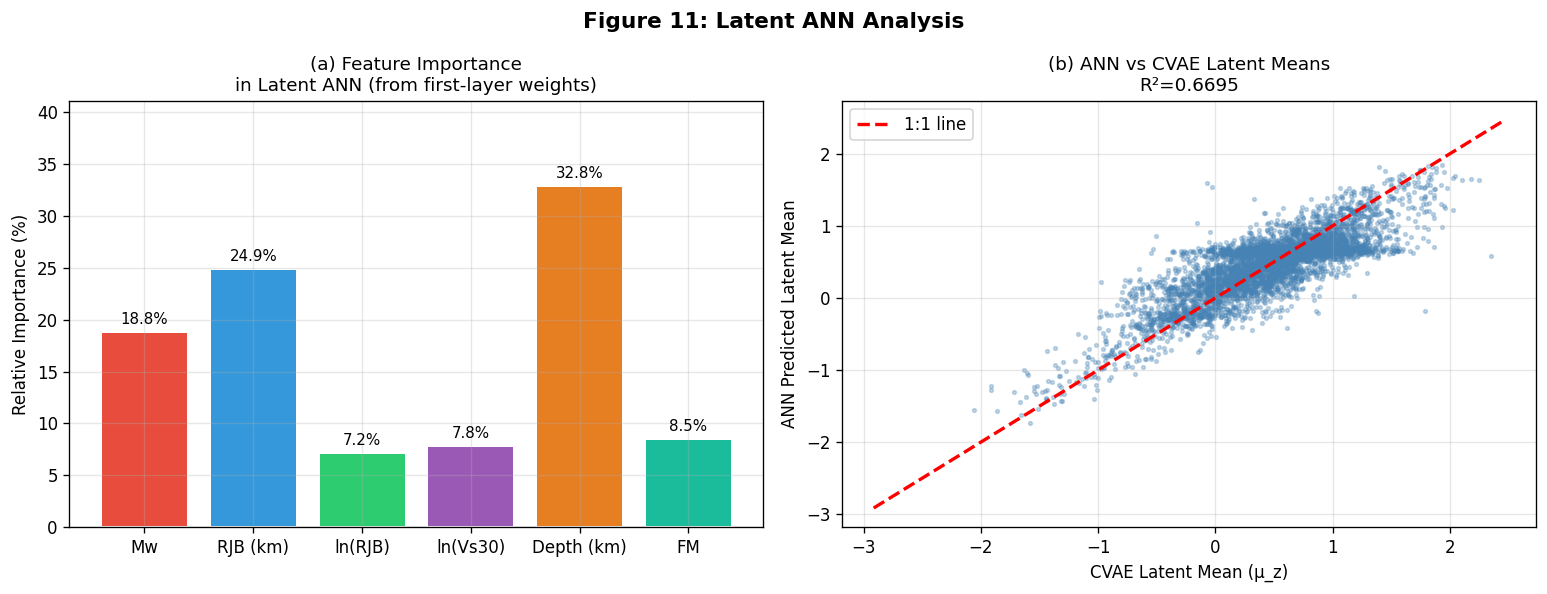

Feature Importance:
  Mw          : 18.83%
  RJB (km)    : 24.88%
  ln(RJB)     : 7.16%
  ln(Vs30)    : 7.79%
  Depth (km)  : 32.85%
  FM          : 8.49%


In [50]:
# ── Extract first layer weights of latent ANN ─────────────────────────────────
# Weight matrix W: (n_cond=6, n_hidden=6)
W1 = latent_ann.layers[1].get_weights()[0]  # shape (6, 6)

# Importance of each input feature = sum of |weight| to all hidden neurons
importance_per_input = np.abs(W1).sum(axis=1)  # (n_cond,)
importance_pct = 100 * importance_per_input / importance_per_input.sum()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel (a): Feature importance bar chart
ax = axes[0]
colors_imp = ['#e74c3c','#3498db','#2ecc71','#9b59b6','#e67e22','#1abc9c']
bars = ax.bar(COND_LABELS, importance_pct, color=colors_imp, edgecolor='white', linewidth=1.2)
ax.set_ylabel('Relative Importance (%)')
ax.set_title('(a) Feature Importance\nin Latent ANN (from first-layer weights)')
ax.set_ylim(0, max(importance_pct)*1.25)
for bar, val in zip(bars, importance_pct):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

# Panel (b): ANN prediction vs CVAE-extracted latent means
ax = axes[1]
ann_pred_mu = latent_ann.predict(C_scaled, verbose=0)
ann_pred_orig = scaler_latent.inverse_transform(ann_pred_mu)
ann_mu_flat   = ann_pred_orig[:, :LATENT_DIM].flatten()
cvae_mu_flat  = z_mean_all.flatten()

# Scatter plot (subsample for visibility)
ss_idx = np.random.choice(len(ann_mu_flat), min(5000, len(ann_mu_flat)), replace=False)
ax.scatter(cvae_mu_flat[ss_idx], ann_mu_flat[ss_idx],
            s=5, alpha=0.3, color='steelblue')
lims = [min(cvae_mu_flat.min(), ann_mu_flat.min()),
        max(cvae_mu_flat.max(), ann_mu_flat.max())]
ax.plot(lims, lims, 'r--', linewidth=2, label='1:1 line')
r2_lat = r2_score(cvae_mu_flat, ann_mu_flat)
ax.set_xlabel('CVAE Latent Mean (μ_z)')
ax.set_ylabel('ANN Predicted Latent Mean')
ax.set_title(f'(b) ANN vs CVAE Latent Means\nR²={r2_lat:.4f}')
ax.legend()

fig.suptitle('Figure 11: Latent ANN Analysis',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fig11_ann_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("Feature Importance:")
for label, imp in zip(COND_LABELS, importance_pct):
    print(f"  {label:<12}: {imp:.2f}%")

## Cell 19 — Figure 12: Predicted SA vs Distance at Multiple Periods

The SA vs distance (attenuation) plot at key periods is a standard validation check for GMMs — we should see a smooth, physics-consistent decay.

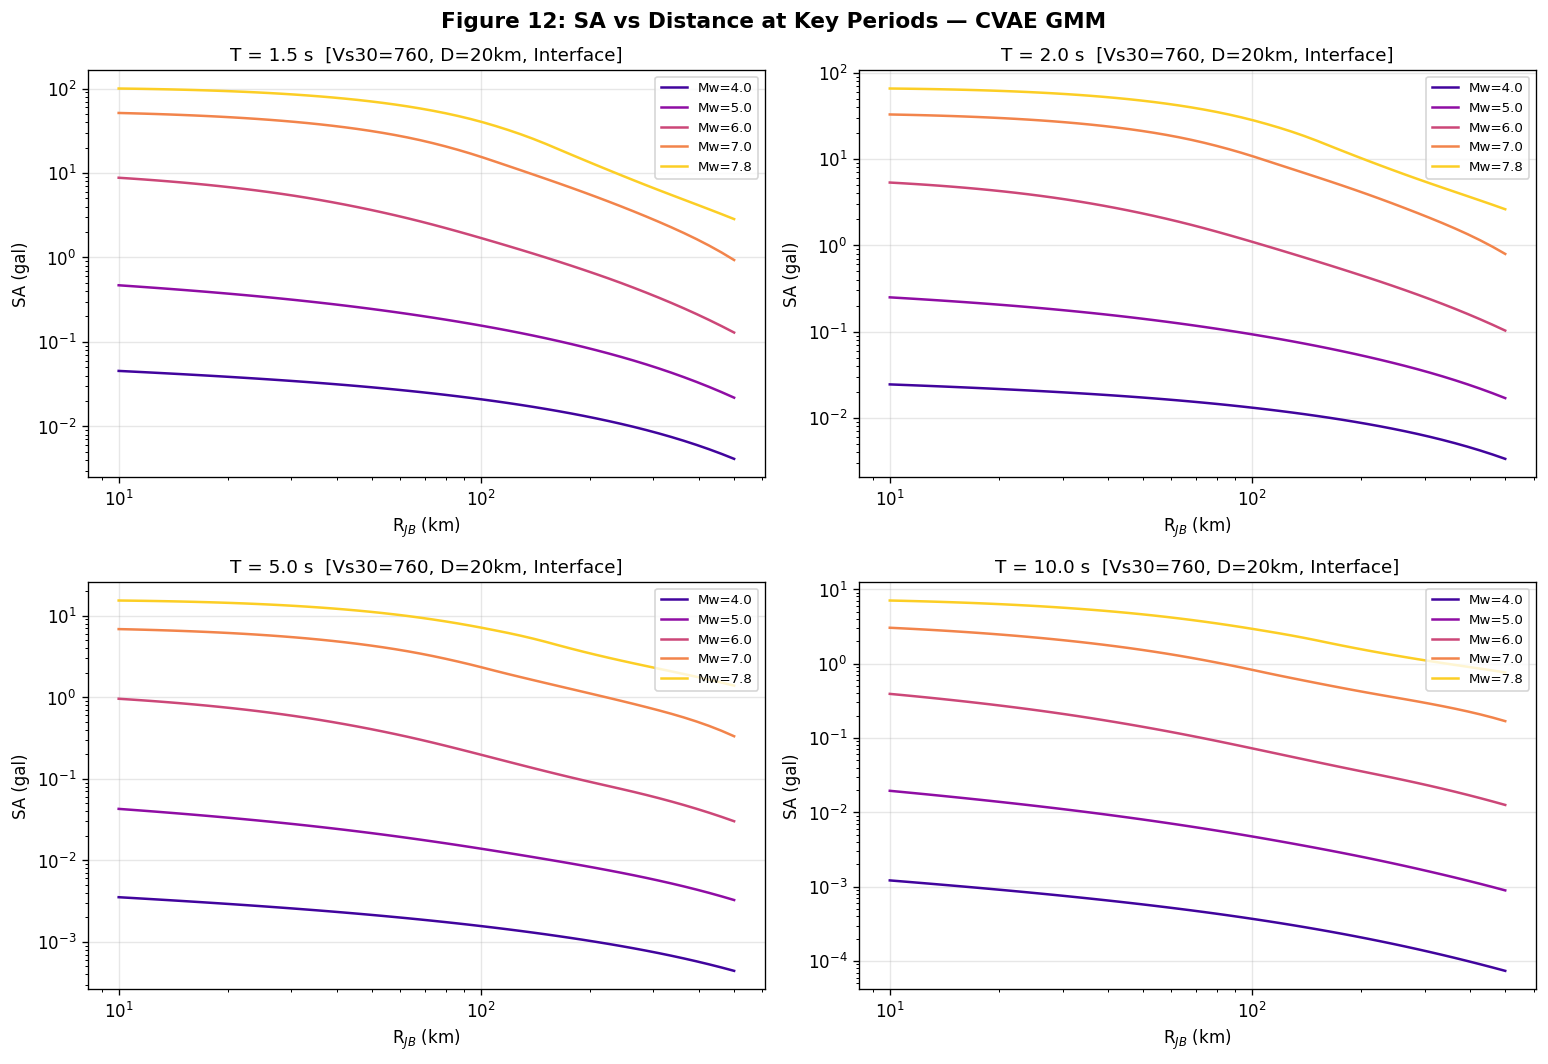

Figure 12 saved.


In [51]:
TARGET_PERIODS = [1.5, 2.0, 5.0, 10.0]
PERIOD_INDICES = [min(range(len(PERIOD_VALUES)), key=lambda i: abs(PERIOD_VALUES[i]-tp)) for tp in TARGET_PERIODS]

R_range = np.logspace(1, 2.7, 50)  # 10 to ~500 km
Mw_set  = [4.0, 5.0, 6.0, 7.0, 7.8]
MW_COLORS = plt.cm.plasma(np.linspace(0.1, 0.9, len(Mw_set)))

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, tp, t_idx in zip(axes.flat, TARGET_PERIODS, PERIOD_INDICES):
    for mw_val, col in zip(Mw_set, MW_COLORS):
        sa_dist = []
        for r_val in R_range:
            sa_full = predict_spectrum(mw_val, r_val, 760, 20, fm=1)
            sa_dist.append(sa_full[t_idx])
        ax.loglog(R_range, sa_dist, color=col, linewidth=1.5, label=f'Mw={mw_val}')
    ax.set_xlabel('R$_{JB}$ (km)'); ax.set_ylabel('SA (gal)')
    ax.set_title(f'T = {tp} s  [Vs30=760, D=20km, Interface]')
    ax.legend(fontsize=8)

fig.suptitle('Figure 12: SA vs Distance at Key Periods — CVAE GMM',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fig12_sa_vs_distance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 12 saved.")

## Cell 20 — Figure 13: SA vs Magnitude at Key Periods

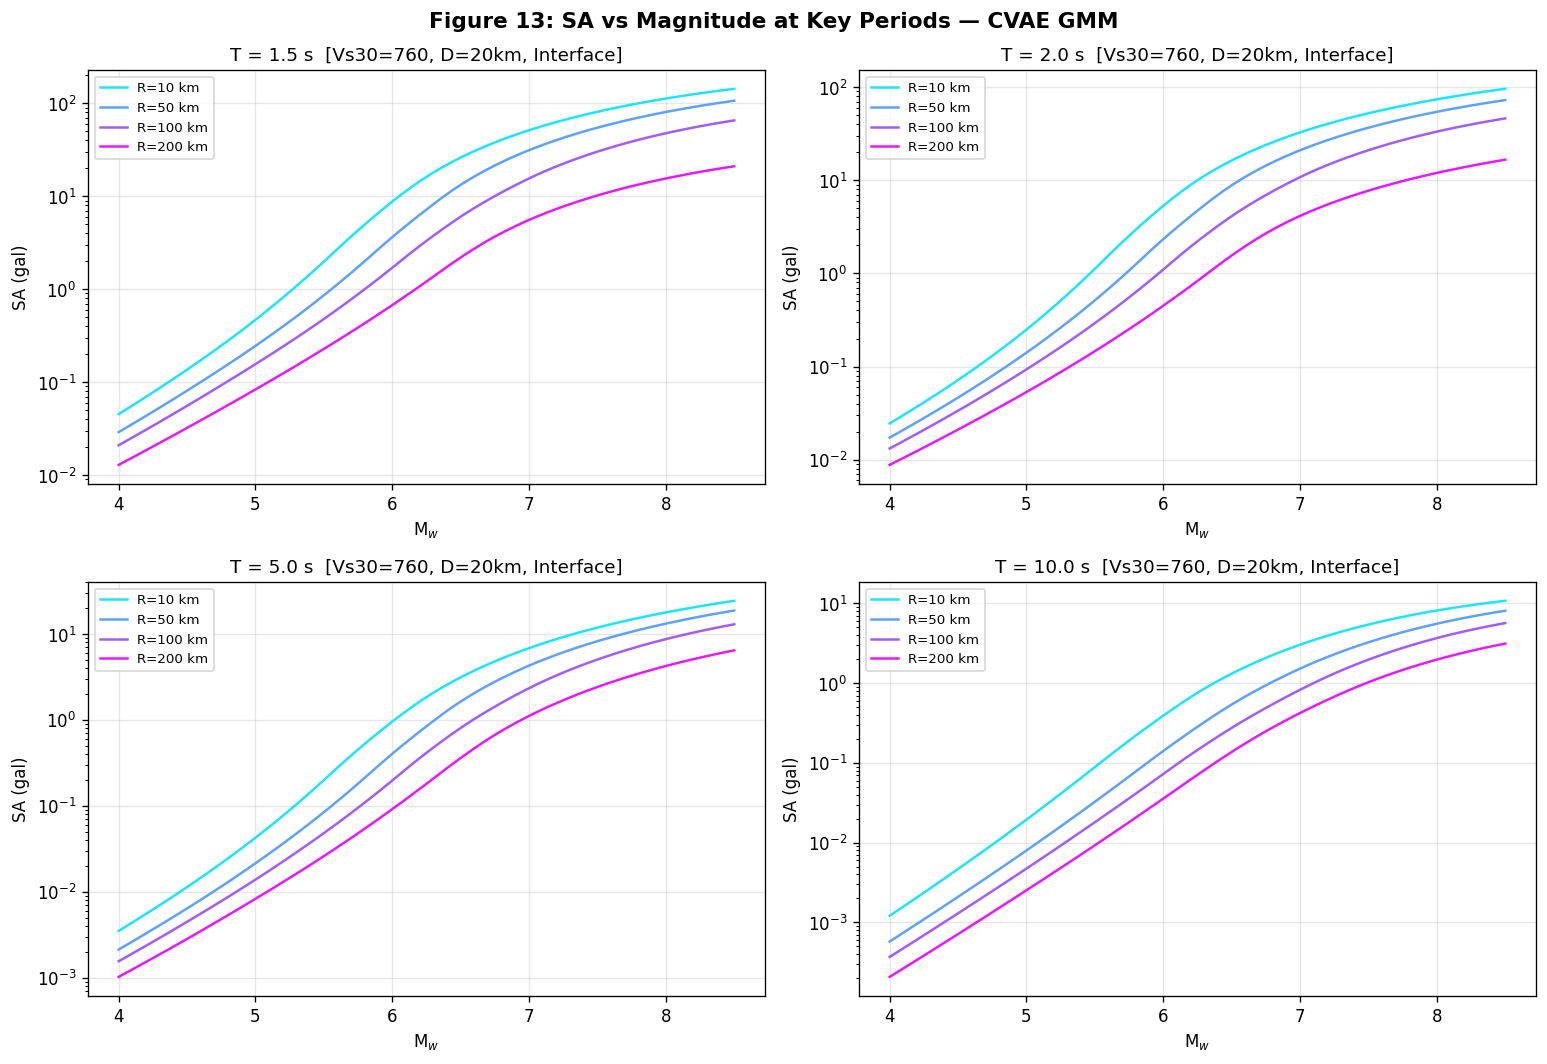

Figure 13 saved.


In [52]:
Mw_range  = np.linspace(4.0, 8.5, 60)
Rjb_set   = [10, 50, 100, 200]
RJB_COLORS = plt.cm.cool(np.linspace(0.1, 0.9, len(Rjb_set)))

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, tp, t_idx in zip(axes.flat, TARGET_PERIODS, PERIOD_INDICES):
    for rjb_val, col in zip(Rjb_set, RJB_COLORS):
        sa_mw = []
        for m_val in Mw_range:
            sa_full = predict_spectrum(m_val, rjb_val, 760, 20, fm=1)
            sa_mw.append(sa_full[t_idx])
        ax.semilogy(Mw_range, sa_mw, color=col, linewidth=1.5, label=f'R={rjb_val} km')
    ax.set_xlabel('M$_w$'); ax.set_ylabel('SA (gal)')
    ax.set_title(f'T = {tp} s  [Vs30=760, D=20km, Interface]')
    ax.legend(fontsize=8)

fig.suptitle('Figure 13: SA vs Magnitude at Key Periods — CVAE GMM',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fig13_sa_vs_magnitude.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 13 saved.")

## Cell 21 — Figure 14: Vs30 Scaling (Soil Amplification)

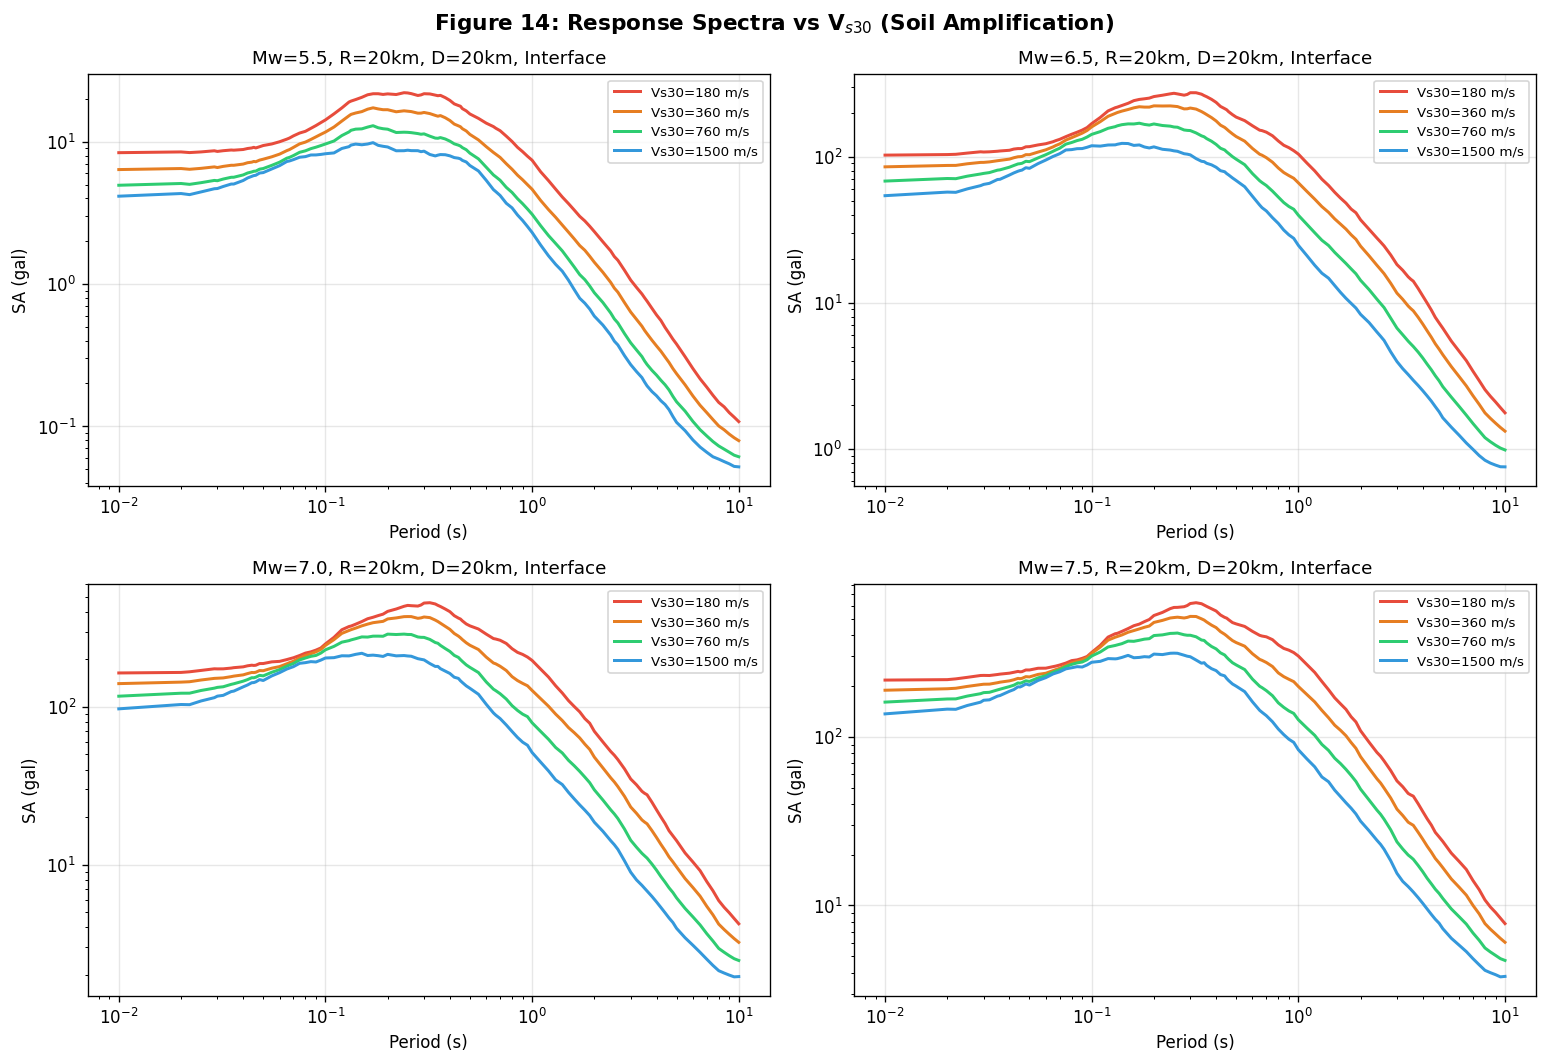

Figure 14 saved.


In [53]:
Mw_for_vs30 = [5.5, 6.5, 7.0, 7.5]
Vs30_set    = [180, 360, 760, 1500]
VS30_COLORS = ['#e74c3c','#e67e22','#2ecc71','#3498db']

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, mw_val in zip(axes.flat, Mw_for_vs30):
    for vs30_val, col in zip(Vs30_set, VS30_COLORS):
        sa = predict_spectrum(mw_val, 20, vs30_val, 20, fm=1)
        ax.loglog(PERIOD_VALUES, sa, color=col, linewidth=1.8,
                   label=f'Vs30={vs30_val} m/s')
    ax.set_xlabel('Period (s)'); ax.set_ylabel('SA (gal)')
    ax.set_title(f'Mw={mw_val}, R=20km, D=20km, Interface')
    ax.legend(fontsize=8)

fig.suptitle('Figure 14: Response Spectra vs V$_{s30}$ (Soil Amplification)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fig14_vs30_scaling.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 14 saved.")

## Cell 22 — Figure 15: Interface vs Intraslab Fault Mechanism

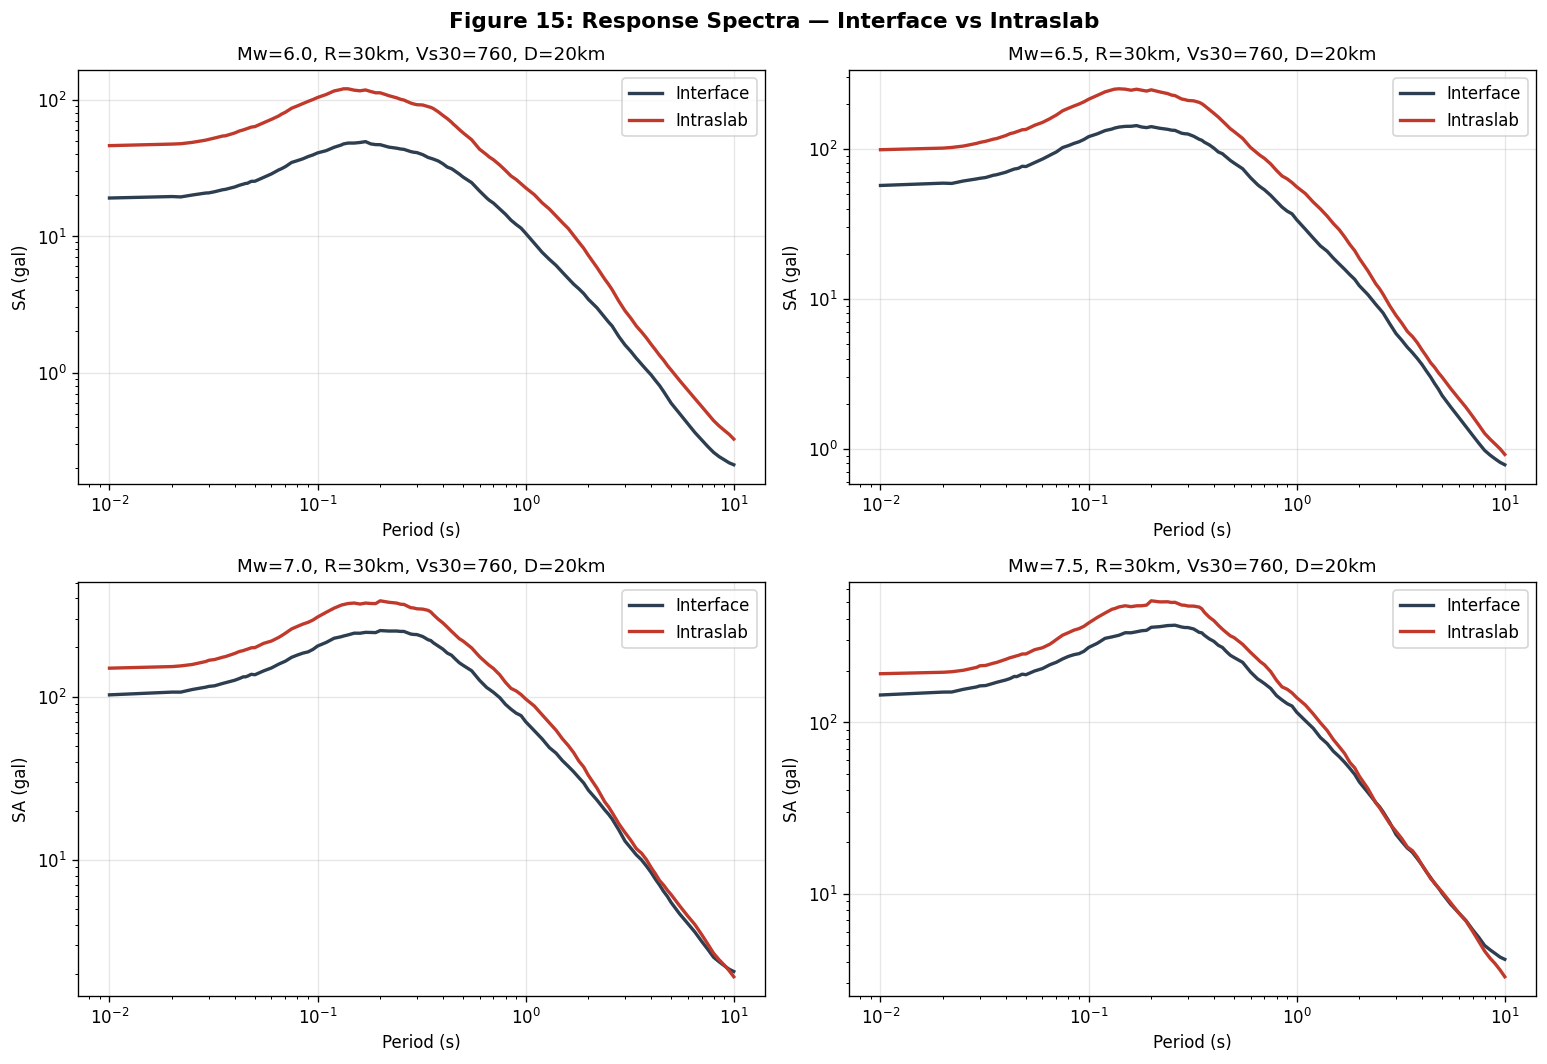

Figure 15 saved.


In [54]:
fm_dict = {1: ('Interface', '#2c3e50'), 2: ('Intraslab', '#c0392b')}
Mw_for_fm = [6.0, 6.5, 7.0, 7.5]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, mw_val in zip(axes.flat, Mw_for_fm):
    for fm_val, (fm_name, col) in fm_dict.items():
        sa = predict_spectrum(mw_val, 30, 760, 20, fm=fm_val)
        ax.loglog(PERIOD_VALUES, sa, color=col, linewidth=2, label=fm_name)
    ax.set_xlabel('Period (s)'); ax.set_ylabel('SA (gal)')
    ax.set_title(f'Mw={mw_val}, R=30km, Vs30=760, D=20km')
    ax.legend()

fig.suptitle('Figure 15: Response Spectra — Interface vs Intraslab',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fig15_fault_mechanism.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 15 saved.")

## Cell 23 — Comprehensive Performance Summary Table

In [55]:
print("=" * 70)
print("CVAE + ANN MODEL — PERFORMANCE SUMMARY")
print("=" * 70)

print("\n[1] Dataset")
print(f"    Records used      : {len(df_model)}")
print(f"    Events            : {len(np.unique(EVENT_IDS))}")
print(f"    Spectral periods  : {N_PERIODS}")
print(f"    Latent dims       : {LATENT_DIM}")
print(f"    Latent ANN R²     : {ann_r2:.4f}")

print("\n[2] CVAE Model")
print(f"    Encoder: {N_PERIODS+N_COND} → 256 → 128 → {LATENT_DIM} (μ) + {LATENT_DIM} (logσ²)")
print(f"    Decoder: {LATENT_DIM+N_COND} → 128 → 256 → {N_PERIODS}")
print(f"    Loss weights: λ₁={LAMBDA1}, λ₂={LAMBDA2}, λ₃={LAMBDA3}")
print(f"    Optimizer: Adam (lr={LR}), batch={BATCH_SIZE}")
print(f"    Training epochs: {len(hist['total_loss'])}")

print("\n[3] Prediction Performance (ANN → CVAE decoder, Test Set)")
print(f"    R²   : {m_ann['r2']:.4f}")
print(f"    RMSE : {m_ann['rmse']:.4f} (ln PSA)")
print(f"    MAE  : {m_ann['mae']:.4f} (ln PSA)")
print(f"    MAPE : {m_ann['mape']:.2f}%")

print("\n[4] Aleatory Variability (Mixed-Effects, full dataset)")
# Summary at a few key periods
key_T_list = [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
print(f"    {'Period(s)':<12} {'τ (inter)':<14} {'φ (intra)':<14} {'σ_total':<12}")
print("    " + "-"*52)
for T_key in key_T_list:
    t_idx = min(range(len(PERIOD_VALUES)), key=lambda i: abs(PERIOD_VALUES[i]-T_key))
    print(f"    {PERIOD_VALUES[t_idx]:<12} {tau_arr[t_idx]:<14.4f} {phi_arr[t_idx]:<14.4f} {sig_arr[t_idx]:<12.4f}")

print("\n[5] Epistemic Uncertainty (CVAE ensemble, log10 scale)")
print(f"    Mean epistemic σ (log10): {epi_std_per_rec.mean():.4f}")
print(f"    Range: [{epi_std_per_rec.min():.4f}, {epi_std_per_rec.max():.4f}]")
print(f"    (Typical ANN: 0.35–0.48; CVAE: much smaller, see paper Table)")

print("\n" + "=" * 70)

CVAE + ANN MODEL — PERFORMANCE SUMMARY

[1] Dataset
    Records used      : 8907
    Events            : 188
    Spectral periods  : 105
    Latent dims       : 3
    Latent ANN R²     : 0.4213

[2] CVAE Model
    Encoder: 111 → 256 → 128 → 3 (μ) + 3 (logσ²)
    Decoder: 9 → 128 → 256 → 105
    Loss weights: λ₁=0.1, λ₂=1.0, λ₃=10.0
    Optimizer: Adam (lr=0.001), batch=32
    Training epochs: 300

[3] Prediction Performance (ANN → CVAE decoder, Test Set)
    R²   : 0.8864
    RMSE : 0.8978 (ln PSA)
    MAE  : 0.6990 (ln PSA)
    MAPE : 127.50%

[4] Aleatory Variability (Mixed-Effects, full dataset)
    Period(s)    τ (inter)      φ (intra)      σ_total     
    ----------------------------------------------------
    0.01         0.7321         0.7622         1.0569      
    0.1          0.8372         0.8743         1.2105      
    0.5          0.6661         0.7625         1.0125      
    1.0          0.6287         0.7211         0.9567      
    2.0          0.5833         0.706

## Cell 24 — Save Models & Scalers

In [56]:
# ── Save CVAE components ──────────────────────────────────────────────────────
encoder.save('models/cvae_encoder.keras')
decoder.save('models/cvae_decoder.keras')
latent_ann.save('models/latent_ann.keras')

# ── Save scalers (needed for inference) ──────────────────────────────────────
with open('models/scalers.pkl', 'wb') as f:
    pickle.dump({
        'scaler_C': scaler_C,
        'scaler_X': scaler_X,
        'scaler_latent': scaler_latent,
    }, f)

# ── Save training history ─────────────────────────────────────────────────────
with open('models/training_history.pkl', 'wb') as f:
    pickle.dump(hist, f)

# ── Save metrics ──────────────────────────────────────────────────────────────
results = {
    'metrics_cvae':      m_cvae,
    'metrics_ann_cvae':  m_ann,
    'tau': tau_arr.tolist(),
    'phi': phi_arr.tolist(),
    'sigma_total': sig_arr.tolist(),
    'epi_std_per_period': epi_std_per_T.tolist(),
    'period_values': PERIOD_VALUES,
}
with open('models/results.pkl', 'wb') as f:
    pickle.dump(results, f)

print("Saved:")
print("  models/cvae_encoder.keras")
print("  models/cvae_decoder.keras")
print("  models/latent_ann.keras")
print("  models/scalers.pkl")
print("  models/training_history.pkl")
print("  models/results.pkl")
print("\nAll figures saved to:  figures/")

Saved:
  models/cvae_encoder.keras
  models/cvae_decoder.keras
  models/latent_ann.keras
  models/scalers.pkl
  models/training_history.pkl
  models/results.pkl

All figures saved to:  figures/


## Cell 25 — Inference Helper: How to Use the Saved Model

This cell shows a **minimal example** of how to load the saved models and predict response spectra for a new earthquake scenario — useful for running the GMM in other scripts or notebooks.

In [57]:
def load_cvae_gmm(model_dir='models'):
    """Load the full CVAE + ANN GMM from saved files."""
    _enc = keras.models.load_model(f'{model_dir}/cvae_encoder.keras',
                                    custom_objects={'Sampling': Sampling})
    _dec = keras.models.load_model(f'{model_dir}/cvae_decoder.keras')
    _ann = keras.models.load_model(f'{model_dir}/latent_ann.keras')
    with open(f'{model_dir}/scalers.pkl', 'rb') as f:
        _sc = pickle.load(f)
    return _enc, _dec, _ann, _sc


def predict_gmm(mw, rjb, vs30, depth, fm, enc, dec, ann, sc,
                n_samples=100, return_gal=True):
    """
    Full inference pipeline for a single earthquake scenario.
    
    Returns
    -------
    median_sa  : ndarray (N_PERIODS,) — median prediction
    ensemble   : ndarray (n_samples, N_PERIODS) — full ensemble
    periods    : list — period values
    """
    log_rjb  = np.log(max(rjb, 0.01))
    log_vs30 = np.log(vs30)
    c_raw = np.array([[mw, rjb, log_rjb, log_vs30, depth, fm]], dtype=np.float32)
    c_sc  = sc['scaler_C'].transform(c_raw).astype(np.float32)

    # ANN → latent distribution
    ao   = sc['scaler_latent'].inverse_transform(ann.predict(c_sc, verbose=0))
    mu_z = ao[:, :LATENT_DIM].astype(np.float32)
    lv_z = ao[:, LATENT_DIM:].astype(np.float32)
    std_z = np.exp(0.5 * lv_z)

    # Sample ensemble
    ensemble = []
    for _ in range(n_samples):
        z_s  = (mu_z + std_z * np.random.randn(1, LATENT_DIM)).astype(np.float32)
        x_s  = dec.predict([z_s, c_sc], verbose=0)
        ln_s = sc['scaler_X'].inverse_transform(x_s)[0]
        sa_s = np.exp(ln_s) * (981.0 if return_gal else 1.0)
        ensemble.append(sa_s)

    ensemble   = np.array(ensemble)
    median_sa  = np.median(ensemble, axis=0)
    return median_sa, ensemble, PERIOD_VALUES


# ── Quick test ────────────────────────────────────────────────────────────────
med, ens, T = predict_gmm(
    mw=7.5, rjb=50, vs30=600, depth=25, fm=1,
    enc=encoder, dec=decoder, ann=latent_ann, sc={'scaler_C': scaler_C, 'scaler_X': scaler_X, 'scaler_latent': scaler_latent},
    n_samples=50
)
print(f"Sample prediction (Mw=7.5, Rjb=50km, Vs30=600m/s, D=25km, Interface):")
print(f"  Median SA at T=0.01s (PGA≈): {med[0]:.4f} gal")
print(f"  Median SA at T=1.0s        : {med[68]:.4f} gal")
print(f"  Median SA at T=3.0s        : {med[83]:.4f} gal")
print(f"  Ensemble shape: {ens.shape}")
print("\nAll cells complete!")

Sample prediction (Mw=7.5, Rjb=50km, Vs30=600m/s, D=25km, Interface):
  Median SA at T=0.01s (PGA≈): 124.0599 gal
  Median SA at T=1.0s        : 96.3564 gal
  Median SA at T=3.0s        : 21.9496 gal
  Ensemble shape: (50, 105)

All cells complete!


---

## Summary of All Generated Figures

| Figure | File | Description |
|--------|------|-------------|
| Fig 1  | `fig1_dataset_distribution.png` | M-R distribution, magnitude/distance/Vs30/depth histograms |
| Fig 2  | `fig2_spectral_correlation.png` | Spectral correlation matrices (PSA and ln PSA) |
| Fig 3  | `fig3_training_history.png` | CVAE training loss curves (4 components) |
| Fig 4  | `fig4_pc_vs_params.png` | Latent PC scores vs seismological parameters |
| Fig 5  | `fig5_per_period_performance.png` | R² and RMSE per spectral period |
| Fig 6  | `fig6_sample_comparisons.png` | Recorded vs CVAE ensemble (9 sample records) |
| Fig 7  | `fig7_physics_checks.png` | SA vs R, M, Depth, Vs30 |
| Fig 8  | `fig8_epistemic_uncertainty.png` | Epistemic σ distribution and period dependence |
| Fig 9  | `fig9_standard_deviations.png` | τ, φ, σ_total and epistemic vs aleatory |
| Fig 10 | `fig10_residuals.png` | Residuals vs predictor variables |
| Fig 11 | `fig11_ann_analysis.png` | Feature importance and ANN vs CVAE latent |
| Fig 12 | `fig12_sa_vs_distance.png` | SA vs distance at key periods |
| Fig 13 | `fig13_sa_vs_magnitude.png` | SA vs magnitude at key periods |
| Fig 14 | `fig14_vs30_scaling.png` | SA vs Vs30 (soil amplification) |
| Fig 15 | `fig15_fault_mechanism.png` | Interface vs Intraslab comparison |

---

## Key Takeaways

1. **CVAE provides a principled probabilistic framework** for GMM development — the latent space captures the dominant modes of spectral variability

2. **Ensemble generation = epistemic uncertainty** — by sampling from the learned latent distribution, we can generate 100+ spectra per scenario, with the spread reflecting model uncertainty

3. **Epistemic σ << Aleatory σ** — as expected, the CVAE's model uncertainty is much smaller than the natural variability in ground motions

4. **Physics are respected** — distance attenuation, magnitude scaling, depth effects, and soil amplification all emerge naturally from the learned model

5. **Three-component loss** ($\lambda_1=0.1, \lambda_2=1.0, \lambda_3=10.0$) provides a balanced trade-off between KL regularization and reconstruction accuracy